# LSTM Intraday Sequence Extension — RQ1, RQ2 and RQ3

I test whether a small LSTM using the ordered 13:00-14:59 minute path adds information beyond engineered tabular features.

I use this notebook as the **final advanced-modelling extension** of my dissertation.

The existing tabular models compress the pre-15:00 trading day into engineered summary features. The LSTM instead receives an ordered minute-by-minute sequence and asks whether modelling the intraday path directly adds useful predictive information.

## Research questions

- **RQ1 — Direction:** Can the pre-15:00 intraday sequence predict whether SPX rises or falls during the final hour?
- **RQ2 — Magnitude:** Can the sequence predict the absolute size of the final-hour SPX move?
- **RQ3 — Large movement:** Can the sequence identify sessions with elevated probability of a large final-hour move?

## Role in the dissertation

This is **exploratory**, not a replacement for the main classical models.

The main tabular analysis has already been tuned and evaluated. I therefore use a deliberately small LSTM architecture and ask:

> Does explicitly modelling temporal order materially improve the conclusions obtained from the engineered tabular features?

A negative result is still useful. With only hundreds of independent trading sessions, a recurrent neural network may have more capacity than the dataset can reliably support.

## Primary sequence specification

Each sample is one trading session.

The model receives the final **120 completed one-minute observations from 13:00 through 14:59 ET**.

The target remains the same final-hour SPX movement used throughout the dissertation:

> approximately 14:59 close → 15:59 close.

Only information available by the end of the 14:59 minute is used.

## Validation design

- Uses the **strict** extended 2023–2026 dataset.
- Uses only the existing `Train` + `Validation` development period.
- Does **not** use the previously inspected `Test` block for model development.
- Does **not** use the fresh post-17-Jul-2026 holdout.
- Uses 3 expanding chronological outer folds.
- Within each outer-training fold, the last 20% is reserved chronologically for early stopping and classification-threshold selection.
- Scaling is fitted only on the training portion of each fold.
- RQ1 is compared with mean-reversion rules on exactly the same outer-test sessions.
- RQ2 is compared with the training-median magnitude benchmark.
- RQ3 average precision is compared with event prevalence.
- Existing classical OOF predictions are joined by date where available for a secondary overlap comparison.

This design follows the same time-order principle as the dissertation's classical modelling work while avoiding an expensive neural-network hyperparameter search.

In [ ]:
# I resolve the repository root before running any project-relative paths.
from pathlib import Path
import os

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    # Path resolution still works before optional project dependencies are installed.
    def load_dotenv(*args, **kwargs):
        return False


def _find_project_root(start=None):
    location = Path(start or Path.cwd()).resolve()
    for candidate in (location, *location.parents):
        if (candidate / "config.yaml").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing config.yaml.")


PROJECT_ROOT = _find_project_root()
# The original notebooks were written from the repository root. Keeping that
# working directory preserves every existing data, output and model path.
os.chdir(PROJECT_ROOT)
load_dotenv(PROJECT_ROOT / "main.env")
print(f"Project root: {PROJECT_ROOT}")


## 1. TensorFlow/Keras environment

I use `tf.keras.layers.LSTM` with chronological early stopping. TensorFlow's official time-series guidance frames recurrent models around ordered windows of consecutive observations, which is the reason the input here is a 120-minute sequence rather than the existing single daily feature vector.

If TensorFlow is not installed in the project environment, the first cell will provide the installation command rather than silently changing the environment.

In [4]:
# I use this cell for tensorflow/keras environment.
from pathlib import Path
import json
import math
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import spearmanr

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

try:
    import tensorflow as tf
    from tensorflow import keras
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for this notebook.\n"
        "Install it in the same Python environment with:\n\n"
        "    python -m pip install tensorflow\n\n"
        "Then restart the notebook kernel and run again."
    ) from exc

print("TensorFlow version:", tf.__version__)
print("Keras backend:", keras.backend.backend())
print("Detected GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.15.0
Keras backend: tensorflow
Detected GPUs: []


In [5]:
# I use this cell for tensorflow/keras environment.
import sys
import platform
import tensorflow as tf

print("OS:", platform.platform())
print("Python:", sys.version)
print("Python executable:", sys.executable)
print("TensorFlow:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs TensorFlow sees:", tf.config.list_physical_devices("GPU"))
print("TF build info:", tf.sysconfig.get_build_info())

OS: Windows-10-10.0.26200-SP0
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Python executable: c:\Users\hkhat\AppData\Local\Programs\Python\Python311\python.exe
TensorFlow: 2.15.0
Built with CUDA: False
GPUs TensorFlow sees: []
TF build info: OrderedDict([('is_cuda_build', False), ('is_rocm_build', False), ('is_tensorrt_build', False), ('msvcp_dll_names', 'msvcp140.dll,msvcp140_1.dll')])


In [6]:
!nvidia-smi

Sun Aug  9 13:53:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.14                 Driver Version: 566.14         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   63C    P8              4W /   95W |     291MiB /   8188MiB |     22%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Reproducibility and modelling configuration

In [7]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations enabled.")
except Exception:
    print(
        "Deterministic-op mode was not available in this TensorFlow build; "
        "random seeds are still fixed."
    )

# ------------------------------------------------------------
# Primary sequence specification
# ------------------------------------------------------------
SEQUENCE_START_MINUTE = 13 * 60      # 13:00
SEQUENCE_END_MINUTE = 14 * 60 + 59  # 14:59
SEQUENCE_LENGTH = (
    SEQUENCE_END_MINUTE
    - SEQUENCE_START_MINUTE
    + 1
)

# ------------------------------------------------------------
# Temporal evaluation
# ------------------------------------------------------------
OUTER_SPLITS = 3
INNER_VALIDATION_FRACTION = 0.20

# ------------------------------------------------------------
# Small, deliberately regularised architecture
# ------------------------------------------------------------
LSTM_UNITS = 32
DENSE_UNITS = 16
DROPOUT_RATE = 0.20
LEARNING_RATE = 0.001

MAX_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 15
MIN_EPOCHS_BEFORE_STOPPING = 5
BATCH_SIZE = 32

# ------------------------------------------------------------
# Sequence permutation-importance diagnostics
# ------------------------------------------------------------
PERMUTATION_REPEATS = 5

# Do not enable simply to search for a better result.
RUN_EXISTING_TEST_AS_SECONDARY_CHECK = False

print("Sequence length:", SEQUENCE_LENGTH, "minutes")
print("Outer folds:", OUTER_SPLITS)
print("Max epochs:", MAX_EPOCHS)

TensorFlow deterministic operations enabled.
Sequence length: 120 minutes
Outer folds: 3
Max epochs: 150


## 3. Locate the extended dataset

I use the artefacts created by:

`10_extended_2023_2026_full_pipeline.ipynb`

Specifically:

- `data_extended_2023_2026/derived/aligned_underlyings_1min.parquet`
- `data_extended_2023_2026/derived/daily_underlying_model_dataset_strict_split.parquet`
- the existing extended classical-model OOF predictions, when available.

In [8]:
# I use this cell for locate the extended dataset.
def locate_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        required = (
            candidate
            / "data_extended_2023_2026"
            / "derived"
            / "aligned_underlyings_1min.parquet"
        )

        if required.exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the extended 2023–2026 derived data. "
        "Place this notebook inside the dissertation project after running "
        "10_extended_2023_2026_full_pipeline.ipynb."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())

DATA_ROOT = PROJECT_ROOT / "data_extended_2023_2026"
DERIVED_ROOT = DATA_ROOT / "derived"

EXTENDED_OUTPUT_ROOT = (
    PROJECT_ROOT / "outputs" / "extended_2023_2026"
)

LSTM_ROOT = EXTENDED_OUTPUT_ROOT / "lstm_sequence_extension"
TABLE_ROOT = LSTM_ROOT / "tables"
FIGURE_ROOT = LSTM_ROOT / "figures"
MODEL_ROOT = LSTM_ROOT / "models"

for path in [
    LSTM_ROOT,
    TABLE_ROOT,
    FIGURE_ROOT,
    MODEL_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

ALIGNED_PATH = (
    DERIVED_ROOT / "aligned_underlyings_1min.parquet"
)

STRICT_SPLIT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict_split.parquet"
)

CLASSICAL_OOF_PATH = (
    EXTENDED_OUTPUT_ROOT
    / "hyperparameter_tuning"
    / "tables"
    / "selected_winner_outer_fold_predictions.csv"
)

CLASSICAL_WINNERS_PATH = (
    EXTENDED_OUTPUT_ROOT
    / "hyperparameter_tuning"
    / "tables"
    / "nested_tuned_winners.csv"
)

print("Project root:", PROJECT_ROOT)
print("LSTM output:", LSTM_ROOT)
print("Aligned minute data:", ALIGNED_PATH)
print("Strict daily labels:", STRICT_SPLIT_PATH)

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
LSTM output: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension
Aligned minute data: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\aligned_underlyings_1min.parquet
Strict daily labels: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\data_extended_2023_2026\derived\daily_underlying_model_dataset_strict_split.parquet


## 4. Load minute data and daily targets

In [9]:
# I use this cell for load minute data and daily targets.
aligned = pd.read_parquet(ALIGNED_PATH)
daily = pd.read_parquet(STRICT_SPLIT_PATH)

aligned["session_date"] = pd.to_datetime(
    aligned["session_date"]
).dt.normalize()

aligned["timestamp_utc"] = pd.to_datetime(
    aligned["timestamp_utc"],
    utc=True,
)

aligned["timestamp_et"] = pd.to_datetime(
    aligned["timestamp_et"]
)

daily["session_date"] = pd.to_datetime(
    daily["session_date"]
).dt.normalize()

daily = daily.sort_values(
    "session_date"
).reset_index(drop=True)

print("Aligned minute rows:", len(aligned))
print("Aligned sessions:", aligned["session_date"].nunique())
print("Strict daily sessions:", len(daily))
print(
    "Strict daily range:",
    daily["session_date"].min().date(),
    "to",
    daily["session_date"].max().date(),
)

display(
    daily.groupby("data_split").agg(
        sessions=("session_date", "size"),
        first_date=("session_date", "min"),
        last_date=("session_date", "max"),
        up_rate=("target_up", "mean"),
        mean_abs_move_bps=(
            "final_hour_return",
            lambda x: x.abs().mean() * 10_000,
        ),
    )
)

Aligned minute rows: 344494
Aligned sessions: 887
Strict daily sessions: 680
Strict daily range: 2023-02-15 to 2026-07-17


,sessions,first_date,last_date,up_rate,mean_abs_move_bps
data_split,,,,,
Test,102,2026-01-29,2026-07-17,0.558824,19.687294
Train,475,2023-02-15,2025-07-25,0.498947,21.470158
Validation,103,2025-07-28,2026-01-28,0.456311,15.831260


## 5. Reproduce the RQ2 and RQ3 targets

RQ2 uses absolute final-hour movement in basis points.

RQ3 reproduces the existing dissertation definition: the 75th percentile of absolute final-hour returns in the original strict **Train** split is used as the fixed large-movement threshold.

This keeps the neural-network extension directly comparable with the existing RQ3 analysis.

In [10]:
# I use this cell for reproduce the rq2 and rq3 targets.
LARGE_MOVE_QUANTILE = 0.75

strict_train_abs_returns = (
    daily.loc[
        daily["data_split"].eq("Train"),
        "final_hour_return",
    ]
    .abs()
)

LARGE_MOVE_THRESHOLD_RETURN = float(
    strict_train_abs_returns.quantile(
        LARGE_MOVE_QUANTILE
    )
)

LARGE_MOVE_THRESHOLD_BPS = (
    LARGE_MOVE_THRESHOLD_RETURN * 10_000
)

daily["target_magnitude_bps"] = (
    daily["final_hour_return"].abs() * 10_000
)

daily["target_large_move"] = (
    daily["final_hour_return"].abs()
    >= LARGE_MOVE_THRESHOLD_RETURN
).astype("int8")

print(
    f"Fixed RQ3 large-move threshold: "
    f"{LARGE_MOVE_THRESHOLD_BPS:.2f} bps"
)

display(
    daily.groupby("data_split").agg(
        sessions=("session_date", "size"),
        up_rate=("target_up", "mean"),
        mean_magnitude_bps=(
            "target_magnitude_bps",
            "mean",
        ),
        large_move_rate=(
            "target_large_move",
            "mean",
        ),
    )
)

Fixed RQ3 large-move threshold: 27.58 bps


,sessions,up_rate,mean_magnitude_bps,large_move_rate
data_split,,,,
Test,102,0.558824,19.687294,0.225490
Train,475,0.498947,21.470158,0.250526
Validation,103,0.456311,15.831260,0.165049


# Part A — Build look-ahead-safe minute sequences

## 6. Minute-level sequence features

The LSTM input is deliberately based on relatively stationary or economically interpretable channels rather than raw SPX level.

For every minute up to 14:59, I construct:

- 1-minute SPX log return;
- 5-minute SPX log return;
- 1-minute SPY log return;
- 1-minute VIX log return;
- 5-minute VIX log return;
- VIX level;
- SPX distance from the session open;
- SPY distance from the session open;
- SPX position within the running intraday range;
- 15-minute realised SPX volatility;
- 30-minute realised SPX volatility;
- log SPY minute volume;
- log cumulative SPY volume;
- SPX alignment staleness;
- VIX alignment staleness;
- normalised time within the 13:00–14:59 sequence.

Rolling values are constructed using only the current and earlier minutes.

In [11]:
SEQUENCE_FEATURES = [
    "spx_logret_1m",
    "spx_logret_5m",
    "spy_logret_1m",
    "vix_logret_1m",
    "vix_logret_5m",
    "vix_level",
    "spx_from_open_pct",
    "spy_from_open_pct",
    "spx_running_range_position",
    "spx_rv_15m",
    "spx_rv_30m",
    "spy_log_volume",
    "spy_log_cum_volume",
    "spx_staleness_seconds",
    "vix_staleness_seconds",
    "sequence_time_fraction",
]


def build_session_minute_features(
    session_frame: pd.DataFrame,
) -> pd.DataFrame:
    frame = (
        session_frame
        .sort_values("timestamp_utc")
        .copy()
    )

    # Work only with information at or before 14:59.
    frame = frame[
        frame["clock_minute"]
        <= SEQUENCE_END_MINUTE
    ].copy()

    if frame.empty:
        return frame

    numeric_columns = [
        "spx_open",
        "spx_high",
        "spx_low",
        "spx_close",
        "spy_open",
        "spy_close",
        "spy_volume",
        "vix_close",
        "spx_staleness_seconds",
        "vix_staleness_seconds",
    ]

    for column in numeric_columns:
        frame[column] = pd.to_numeric(
            frame[column],
            errors="coerce",
        )

    # Log-return channels.
    frame["spx_logret_1m"] = np.log(
        frame["spx_close"]
    ).diff()

    frame["spx_logret_5m"] = np.log(
        frame["spx_close"]
    ).diff(5)

    frame["spy_logret_1m"] = np.log(
        frame["spy_close"]
    ).diff()

    frame["vix_logret_1m"] = np.log(
        frame["vix_close"]
    ).diff()

    frame["vix_logret_5m"] = np.log(
        frame["vix_close"]
    ).diff(5)

    frame["vix_level"] = frame["vix_close"]

    # Session-open positioning. The first observed regular-session open is
    # available from the beginning of the day.
    spx_open = frame["spx_open"].dropna().iloc[0]
    spy_open = frame["spy_open"].dropna().iloc[0]

    frame["spx_from_open_pct"] = (
        frame["spx_close"] / spx_open - 1
    )

    frame["spy_from_open_pct"] = (
        frame["spy_close"] / spy_open - 1
    )

    # Running range — no future high/low information is used.
    frame["running_spx_high"] = (
        frame["spx_high"].cummax()
    )

    frame["running_spx_low"] = (
        frame["spx_low"].cummin()
    )

    running_range = (
        frame["running_spx_high"]
        - frame["running_spx_low"]
    )

    frame["spx_running_range_position"] = np.where(
        running_range > 0,
        (
            frame["spx_close"]
            - frame["running_spx_low"]
        )
        / running_range,
        0.5,
    )

    squared_returns = (
        frame["spx_logret_1m"] ** 2
    )

    frame["spx_rv_15m"] = np.sqrt(
        squared_returns.rolling(
            15,
            min_periods=10,
        ).sum()
    )

    frame["spx_rv_30m"] = np.sqrt(
        squared_returns.rolling(
            30,
            min_periods=20,
        ).sum()
    )

    volume = frame["spy_volume"].clip(lower=0)

    frame["spy_log_volume"] = np.log1p(
        volume
    )

    frame["spy_log_cum_volume"] = np.log1p(
        volume.fillna(0).cumsum()
    )

    sequence_mask = frame[
        "clock_minute"
    ].between(
        SEQUENCE_START_MINUTE,
        SEQUENCE_END_MINUTE,
    )

    sequence = frame.loc[
        sequence_mask
    ].copy()

    if len(sequence):
        sequence[
            "sequence_time_fraction"
        ] = np.linspace(
            0.0,
            1.0,
            len(sequence),
        )

    return sequence


sequence_frames = []
sequence_quality_rows = []

strict_dates = set(
    daily["session_date"]
)

for session_date, group in aligned.groupby(
    "session_date",
    sort=True,
):
    if session_date not in strict_dates:
        continue

    try:
        seq = build_session_minute_features(
            group
        )
    except Exception as exc:
        sequence_quality_rows.append(
            {
                "session_date": session_date,
                "rows": 0,
                "complete": False,
                "missing_feature_values": np.nan,
                "error": str(exc)[:500],
            }
        )
        continue

    missing_values = (
        seq[SEQUENCE_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
        .isna()
        .sum()
        .sum()
        if len(seq)
        else np.nan
    )

    complete = (
        len(seq) == SEQUENCE_LENGTH
        and missing_values == 0
        and seq["clock_minute"].min()
        == SEQUENCE_START_MINUTE
        and seq["clock_minute"].max()
        == SEQUENCE_END_MINUTE
    )

    sequence_quality_rows.append(
        {
            "session_date": session_date,
            "rows": len(seq),
            "complete": bool(complete),
            "missing_feature_values": missing_values,
            "error": None,
        }
    )

    if complete:
        sequence_frames.append(
            seq[
                [
                    "session_date",
                    "timestamp_et",
                    "clock_minute",
                    *SEQUENCE_FEATURES,
                ]
            ].copy()
        )

sequence_quality = pd.DataFrame(
    sequence_quality_rows
)

minute_sequences = pd.concat(
    sequence_frames,
    ignore_index=True,
)

print("Strict daily sessions:", len(daily))
print(
    "Complete 120-minute LSTM sequences:",
    sequence_quality["complete"].sum(),
)
print(
    "Excluded sequence sessions:",
    (~sequence_quality["complete"]).sum(),
)

display(
    sequence_quality[
        ~sequence_quality["complete"]
    ].head(30)
)

Strict daily sessions: 680
Complete 120-minute LSTM sequences: 675
Excluded sequence sessions: 5


,session_date,rows,complete,missing_feature_values,error
168,2023-11-28,120,False,3,None
186,2024-02-09,120,False,1,None
197,2024-03-21,120,False,1,None
228,2024-06-05,120,False,1,None
433,2025-05-13,120,False,1,None


## 7. Join sequence availability to the daily targets

In [12]:
complete_dates = set(
    sequence_quality.loc[
        sequence_quality["complete"],
        "session_date",
    ]
)

sequence_daily = (
    daily[
        daily["session_date"].isin(
            complete_dates
        )
    ]
    .sort_values("session_date")
    .reset_index(drop=True)
)

# Main development set: identical principle to the tuned classical workflow.
development_daily = (
    sequence_daily[
        sequence_daily["data_split"].isin(
            ["Train", "Validation"]
        )
    ]
    .sort_values("session_date")
    .reset_index(drop=True)
)

existing_test_daily = (
    sequence_daily[
        sequence_daily["data_split"].eq("Test")
    ]
    .sort_values("session_date")
    .reset_index(drop=True)
)

print(
    "Sequence-eligible development sessions:",
    len(development_daily),
)
print(
    "Sequence-eligible previously inspected test sessions:",
    len(existing_test_daily),
)

print(
    "Development range:",
    development_daily["session_date"].min().date(),
    "to",
    development_daily["session_date"].max().date(),
)

assert (
    development_daily["session_date"].max()
    <
    existing_test_daily["session_date"].min()
)

display(
    development_daily[
        [
            "session_date",
            "target_up",
            "target_magnitude_bps",
            "target_large_move",
            "ret_last_15m",
            "ret_last_60m",
        ]
    ].head()
)

Sequence-eligible development sessions: 573
Sequence-eligible previously inspected test sessions: 102
Development range: 2023-02-15 to 2026-01-28


,session_date,target_up,target_magnitude_bps,target_large_move,ret_last_15m,ret_last_60m
0,2023-02-15,1,36.905013,1,-0.002417,-0.001322
1,2023-02-16,0,95.886795,1,-0.000363,0.000170
2,2023-02-17,1,2.648422,0,0.002168,0.004815
3,2023-02-21,0,16.135075,0,-0.000454,0.000137
4,2023-02-22,1,22.699423,0,-0.002142,-0.006821


## 8. Convert sessions to the three-dimensional LSTM tensor

In [13]:
# I use this cell for convert sessions to the three-dimensional lstm tensor.
sequence_lookup = {
    session_date: (
        group.sort_values(
            "clock_minute"
        )[SEQUENCE_FEATURES]
        .to_numpy(dtype=np.float32)
    )
    for session_date, group
    in minute_sequences.groupby(
        "session_date",
        sort=False,
    )
}


def build_X_for_dates(
    dates: pd.Series,
) -> np.ndarray:
    arrays = [
        sequence_lookup[
            pd.Timestamp(date).normalize()
        ]
        for date in dates
    ]

    X = np.stack(
        arrays,
        axis=0,
    ).astype(np.float32)

    if X.shape[1] != SEQUENCE_LENGTH:
        raise RuntimeError(
            f"Unexpected sequence shape: {X.shape}"
        )

    return X


X_development = build_X_for_dates(
    development_daily["session_date"]
)

y_rq1 = development_daily[
    "target_up"
].to_numpy(dtype=np.int32)

y_rq2 = development_daily[
    "target_magnitude_bps"
].to_numpy(dtype=np.float32)

y_rq3 = development_daily[
    "target_large_move"
].to_numpy(dtype=np.int32)

print(
    "Development tensor shape:",
    X_development.shape,
)
print(
    "Dimensions = sessions × minutes × features"
)
print("Number of sequence features:", len(SEQUENCE_FEATURES))

assert np.isfinite(
    X_development
).all()

assert (
    X_development.shape[0]
    == len(development_daily)
)

Development tensor shape: (573, 120, 16)
Dimensions = sessions × minutes × features
Number of sequence features: 16


## 9. Visualise a few sequence channels

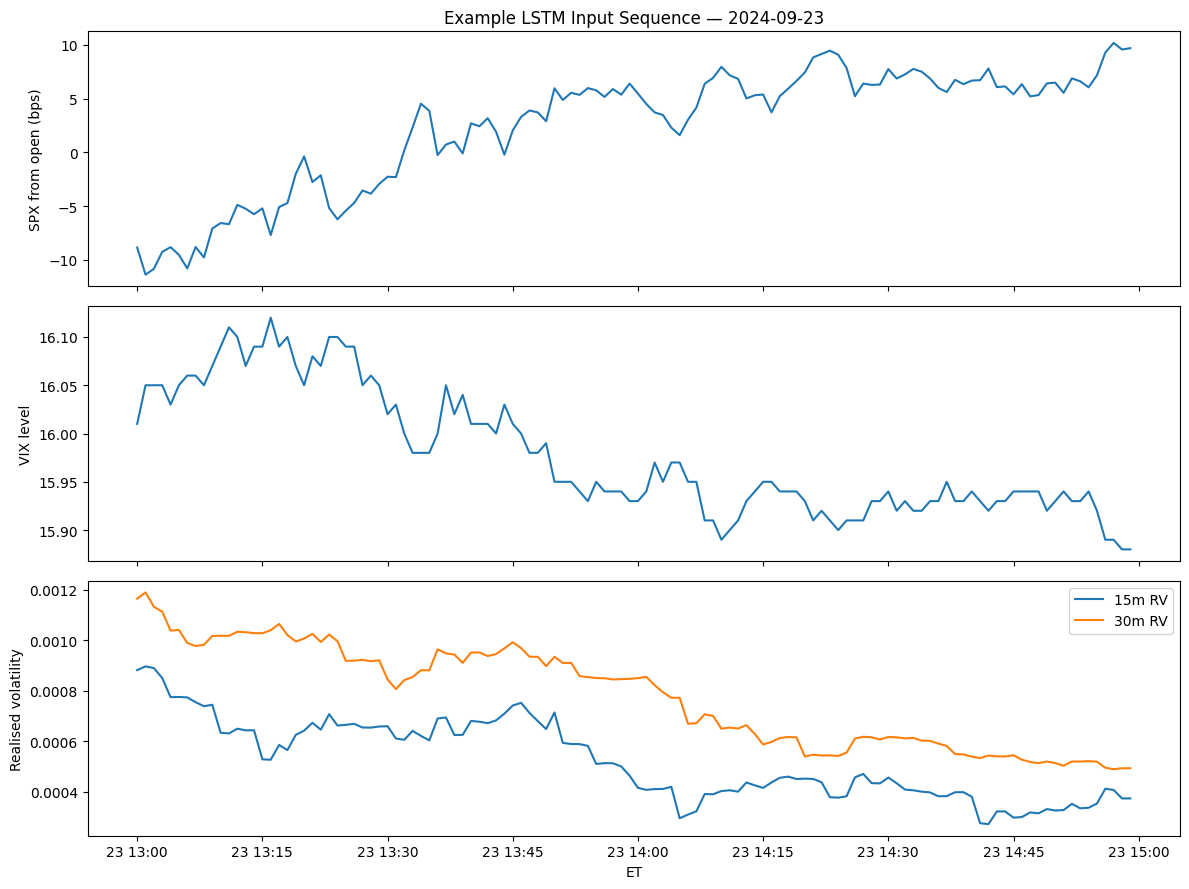

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\figures\lstm_example_input_sequence.png


In [14]:
# I use this cell for visualise a few sequence channels.
example_date = development_daily.iloc[
    len(development_daily) // 2
]["session_date"]

example = minute_sequences[
    minute_sequences["session_date"].eq(
        example_date
    )
].sort_values("clock_minute")

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 9),
    sharex=True,
)

axes[0].plot(
    example["timestamp_et"],
    10_000 * example["spx_from_open_pct"],
)
axes[0].set_ylabel("SPX from open (bps)")
axes[0].set_title(
    f"Example LSTM Input Sequence — "
    f"{example_date.date()}"
)

axes[1].plot(
    example["timestamp_et"],
    example["vix_level"],
)
axes[1].set_ylabel("VIX level")

axes[2].plot(
    example["timestamp_et"],
    example["spx_rv_15m"],
    label="15m RV",
)
axes[2].plot(
    example["timestamp_et"],
    example["spx_rv_30m"],
    label="30m RV",
)
axes[2].set_ylabel("Realised volatility")
axes[2].set_xlabel("ET")
axes[2].legend()

fig.tight_layout()

example_path = (
    FIGURE_ROOT
    / "lstm_example_input_sequence.png"
)

fig.savefig(
    example_path,
    dpi=220,
    bbox_inches="tight",
)
plt.show()

print("Saved:", example_path)

# Part B — Leakage-safe LSTM utilities

## 10. Scaling, metrics and threshold selection

In [15]:
# I use this cell for scaling, metrics and threshold selection.
def scale_3d_train_validation_test(
    X_train,
    X_validation,
    X_test,
):
    n_features = X_train.shape[-1]

    scaler = StandardScaler()

    scaler.fit(
        X_train.reshape(
            -1,
            n_features,
        )
    )

    def transform(X):
        shape = X.shape

        transformed = scaler.transform(
            X.reshape(
                -1,
                n_features,
            )
        )

        return transformed.reshape(
            shape
        ).astype(np.float32)

    return (
        transform(X_train),
        transform(X_validation),
        transform(X_test),
        scaler,
    )


def safe_roc_auc(
    y_true,
    scores,
):
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(
        roc_auc_score(
            y_true,
            scores,
        )
    )


def safe_average_precision(
    y_true,
    scores,
):
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(
        average_precision_score(
            y_true,
            scores,
        )
    )


def classification_metrics(
    y_true,
    predictions,
    scores,
):
    return {
        "accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                predictions,
            )
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            predictions,
        ),
        "roc_auc": safe_roc_auc(
            y_true,
            scores,
        ),
        "average_precision": (
            safe_average_precision(
                y_true,
                scores,
            )
        ),
    }


def regression_metrics(
    y_true,
    predictions,
):
    rank = spearmanr(
        y_true,
        predictions,
        nan_policy="omit",
    ).statistic

    return {
        "mae_bps": mean_absolute_error(
            y_true,
            predictions,
        ),
        "rmse_bps": math.sqrt(
            mean_squared_error(
                y_true,
                predictions,
            )
        ),
        "r2": r2_score(
            y_true,
            predictions,
        ),
        "spearman": rank,
    }


def select_threshold(
    y_true,
    scores,
    objective,
):
    scores = np.asarray(
        scores,
        dtype=float,
    )

    if len(np.unique(scores)) < 2:
        return 0.5, np.nan

    quantiles = np.linspace(
        0.02,
        0.98,
        97,
    )

    candidates = np.unique(
        np.concatenate(
            [
                np.quantile(
                    scores,
                    quantiles,
                ),
                np.array([0.5]),
            ]
        )
    )

    rows = []

    for threshold in candidates:
        pred = (
            scores >= threshold
        ).astype(int)

        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(
                y_true,
                pred,
            )

        elif objective == "f1":
            value = f1_score(
                y_true,
                pred,
                zero_division=0,
            )

        else:
            raise ValueError(
                f"Unknown threshold objective: "
                f"{objective}"
            )

        rows.append(
            (
                float(threshold),
                float(value),
            )
        )

    rows.sort(
        key=lambda x: (
            -x[1],
            x[0],
        )
    )

    return rows[0]

## 11. Model builders

In [16]:
# I use this cell for model builders.
def build_lstm_model(
    n_features: int,
    task: str,
):
    inputs = keras.Input(
        shape=(
            SEQUENCE_LENGTH,
            n_features,
        ),
        name="intraday_sequence",
    )

    x = keras.layers.LSTM(
        LSTM_UNITS,
        activation="tanh",
        recurrent_activation="sigmoid",
        return_sequences=False,
        name="lstm",
    )(inputs)

    x = keras.layers.Dense(
        DENSE_UNITS,
        activation="relu",
        name="dense_hidden",
    )(x)

    x = keras.layers.Dropout(
        DROPOUT_RATE,
        seed=RANDOM_STATE,
        name="dropout",
    )(x)

    if task in {
        "RQ1",
        "RQ3",
    }:
        outputs = keras.layers.Dense(
            1,
            activation="sigmoid",
            name="probability",
        )(x)

        model = keras.Model(
            inputs=inputs,
            outputs=outputs,
        )

        model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=LEARNING_RATE
            ),
            loss="binary_crossentropy",
            metrics=[
                keras.metrics.BinaryAccuracy(
                    name="accuracy"
                ),
                keras.metrics.AUC(
                    curve="ROC",
                    name="roc_auc",
                ),
                keras.metrics.AUC(
                    curve="PR",
                    name="pr_auc",
                ),
            ],
        )

        return model

    if task == "RQ2":
        outputs = keras.layers.Dense(
            1,
            activation="linear",
            name="magnitude_bps",
        )(x)

        model = keras.Model(
            inputs=inputs,
            outputs=outputs,
        )

        model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=LEARNING_RATE
            ),
            loss="mae",
            metrics=[
                keras.metrics.MeanAbsoluteError(
                    name="mae"
                )
            ],
        )

        return model

    raise ValueError(
        f"Unsupported task: {task}"
    )


example_model = build_lstm_model(
    len(SEQUENCE_FEATURES),
    "RQ1",
)

example_model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 intraday_sequence (InputLa  [(None, 120, 16)]         0         
 yer)                                                            
                                                                 
 lstm (LSTM)                 (None, 32)                6272      
                                                                 
 dense_hidden (Dense)        (None, 16)                528       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 probability (Dense)         (None, 1)                 17        
                                                                 
Total params: 6817 (26.63 KB)
Trainable params: 6817 (26.63 KB)
Non-trainable params: 0 (0.00 Byte)
__________________________

## 12. Chronological outer-fold training

The neural network is **not hyperparameter-tuned across dozens of configurations**.

For each outer fold:

1. use the expanding historical outer-training period;
2. reserve its most recent 20% as an internal chronological validation tail;
3. fit the feature scaler on the earlier fit portion only;
4. train with early stopping;
5. select the RQ1/RQ3 classification threshold using only the internal validation tail;
6. evaluate once on the outer-test period.

The model that generated each outer-test prediction therefore had no access to that test observation.

In [17]:
# I use this cell for chronological outer-fold training.
def chronological_fit_validation_split(
    outer_train_indices,
):
    n = len(outer_train_indices)

    validation_size = max(
        1,
        int(
            math.ceil(
                n
                * INNER_VALIDATION_FRACTION
            )
        ),
    )

    if n - validation_size < 30:
        raise RuntimeError(
            "Outer training fold is too small "
            "for the requested internal validation."
        )

    fit_indices = (
        outer_train_indices[
            :-validation_size
        ]
    )

    validation_indices = (
        outer_train_indices[
            -validation_size:
        ]
    )

    return (
        fit_indices,
        validation_indices,
    )


def classification_class_weight(
    y_train,
):
    classes = np.unique(
        y_train
    )

    if len(classes) < 2:
        return None

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )

    return {
        int(cls): float(weight)
        for cls, weight
        in zip(
            classes,
            weights,
        )
    }


def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            start_from_epoch=(
                MIN_EPOCHS_BEFORE_STOPPING
            ),
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(
                4,
                EARLY_STOPPING_PATIENCE // 3,
            ),
            min_lr=1e-5,
            verbose=0,
        ),
    ]

## 13. Sequence-feature permutation importance

For each fitted outer-fold model, one input channel is permuted **across sessions while its 120-minute within-session shape is preserved**.

A positive importance means performance worsened after the channel was reassigned to different sessions.

This does not imply causality. It is an exploratory measure of which temporal channels the LSTM relied on.

In [18]:
# I use this cell for sequence-feature permutation importance.
def sequence_permutation_importance(
    model,
    X_test_scaled,
    y_test,
    task,
    threshold=None,
    repeats=PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(
        random_state
    )

    base_scores = (
        model.predict(
            X_test_scaled,
            verbose=0,
        )
        .reshape(-1)
    )

    if task == "RQ1":
        base_pred = (
            base_scores >= threshold
        ).astype(int)

        base_metric = (
            balanced_accuracy_score(
                y_test,
                base_pred,
            )
        )

    elif task == "RQ2":
        base_metric = (
            mean_absolute_error(
                y_test,
                base_scores,
            )
        )

    elif task == "RQ3":
        base_metric = (
            safe_average_precision(
                y_test,
                base_scores,
            )
        )

    else:
        raise ValueError(task)

    rows = []

    for feature_index, feature_name in enumerate(
        SEQUENCE_FEATURES
    ):
        repeat_importance = []

        for repeat in range(repeats):
            X_perm = (
                X_test_scaled.copy()
            )

            order = rng.permutation(
                len(X_perm)
            )

            X_perm[
                :,
                :,
                feature_index,
            ] = X_perm[
                order,
                :,
                feature_index,
            ]

            scores = (
                model.predict(
                    X_perm,
                    verbose=0,
                )
                .reshape(-1)
            )

            if task == "RQ1":
                pred = (
                    scores >= threshold
                ).astype(int)

                metric = (
                    balanced_accuracy_score(
                        y_test,
                        pred,
                    )
                )

                importance = (
                    base_metric - metric
                )

            elif task == "RQ2":
                metric = (
                    mean_absolute_error(
                        y_test,
                        scores,
                    )
                )

                importance = (
                    metric - base_metric
                )

            else:
                metric = (
                    safe_average_precision(
                        y_test,
                        scores,
                    )
                )

                importance = (
                    base_metric - metric
                )

            repeat_importance.append(
                importance
            )

        rows.append(
            {
                "feature": feature_name,
                "importance_mean": (
                    np.mean(
                        repeat_importance
                    )
                ),
                "importance_std": (
                    np.std(
                        repeat_importance,
                        ddof=1,
                    )
                    if len(
                        repeat_importance
                    ) > 1
                    else 0.0
                ),
                "base_metric": base_metric,
            }
        )

    return pd.DataFrame(rows)

# Part C — RQ1: Direction

## 14. RQ1 expanding-fold LSTM evaluation

In [19]:
def run_rq1_lstm():
    outer = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    fold_rows = []
    prediction_rows = []
    importance_rows = []
    history_rows = []

    for outer_fold, (
        outer_train_idx,
        outer_test_idx,
    ) in enumerate(
        outer.split(
            X_development
        ),
        start=1,
    ):
        tf.keras.backend.clear_session()
        tf.random.set_seed(
            RANDOM_STATE + outer_fold
        )

        (
            fit_idx,
            internal_val_idx,
        ) = (
            chronological_fit_validation_split(
                outer_train_idx
            )
        )

        (
            X_fit,
            X_internal_val,
            X_outer_test,
            scaler,
        ) = scale_3d_train_validation_test(
            X_development[
                fit_idx
            ],
            X_development[
                internal_val_idx
            ],
            X_development[
                outer_test_idx
            ],
        )

        y_fit = y_rq1[
            fit_idx
        ]
        y_internal_val = y_rq1[
            internal_val_idx
        ]
        y_outer_test = y_rq1[
            outer_test_idx
        ]

        model = build_lstm_model(
            len(SEQUENCE_FEATURES),
            "RQ1",
        )

        class_weight = (
            classification_class_weight(
                y_fit
            )
        )

        history = model.fit(
            X_fit,
            y_fit,
            validation_data=(
                X_internal_val,
                y_internal_val,
            ),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=False,
            class_weight=class_weight,
            callbacks=make_callbacks(),
            verbose=0,
        )

        best_epoch = int(
            np.argmin(
                history.history[
                    "val_loss"
                ]
            )
            + 1
        )

        internal_scores = (
            model.predict(
                X_internal_val,
                verbose=0,
            )
            .reshape(-1)
        )

        threshold, threshold_objective = (
            select_threshold(
                y_internal_val,
                internal_scores,
                objective=(
                    "balanced_accuracy"
                ),
            )
        )

        outer_scores = (
            model.predict(
                X_outer_test,
                verbose=0,
            )
            .reshape(-1)
        )

        outer_pred = (
            outer_scores
            >= threshold
        ).astype(int)

        metrics = classification_metrics(
            y_outer_test,
            outer_pred,
            outer_scores,
        )

        test_rows = development_daily.iloc[
            outer_test_idx
        ].copy()

        # Fold-matched simple benchmarks.
        mean_reversion_15 = (
            test_rows["ret_last_15m"]
            < 0
        ).astype(int).to_numpy()

        mean_reversion_60 = (
            test_rows["ret_last_60m"]
            < 0
        ).astype(int).to_numpy()

        majority_class = int(
            pd.Series(
                y_rq1[
                    outer_train_idx
                ]
            )
            .mode()
            .iloc[0]
        )

        majority_pred = np.full(
            len(outer_test_idx),
            majority_class,
            dtype=int,
        )

        fold_rows.append(
            {
                "research_question": (
                    "RQ1 Direction"
                ),
                "outer_fold": outer_fold,
                "outer_train_start": (
                    development_daily.iloc[
                        outer_train_idx
                    ]["session_date"].min()
                ),
                "outer_train_end": (
                    development_daily.iloc[
                        outer_train_idx
                    ]["session_date"].max()
                ),
                "outer_test_start": (
                    test_rows[
                        "session_date"
                    ].min()
                ),
                "outer_test_end": (
                    test_rows[
                        "session_date"
                    ].max()
                ),
                "fit_sessions": len(
                    fit_idx
                ),
                "internal_validation_sessions": (
                    len(
                        internal_val_idx
                    )
                ),
                "outer_test_sessions": len(
                    outer_test_idx
                ),
                "best_epoch": best_epoch,
                "threshold": threshold,
                "internal_threshold_balanced_accuracy": (
                    threshold_objective
                ),
                **metrics,
                "majority_balanced_accuracy": (
                    balanced_accuracy_score(
                        y_outer_test,
                        majority_pred,
                    )
                ),
                "mean_reversion_15m_balanced_accuracy": (
                    balanced_accuracy_score(
                        y_outer_test,
                        mean_reversion_15,
                    )
                ),
                "mean_reversion_60m_balanced_accuracy": (
                    balanced_accuracy_score(
                        y_outer_test,
                        mean_reversion_60,
                    )
                ),
            }
        )

        for row_position, source_index in enumerate(
            outer_test_idx
        ):
            prediction_rows.append(
                {
                    "research_question": (
                        "RQ1 Direction"
                    ),
                    "outer_fold": outer_fold,
                    "session_date": (
                        development_daily.iloc[
                            source_index
                        ]["session_date"]
                    ),
                    "y_true": int(
                        y_outer_test[
                            row_position
                        ]
                    ),
                    "score": float(
                        outer_scores[
                            row_position
                        ]
                    ),
                    "prediction": int(
                        outer_pred[
                            row_position
                        ]
                    ),
                    "threshold": (
                        threshold
                    ),
                    "ret_last_15m": float(
                        test_rows.iloc[
                            row_position
                        ][
                            "ret_last_15m"
                        ]
                    ),
                    "ret_last_60m": float(
                        test_rows.iloc[
                            row_position
                        ][
                            "ret_last_60m"
                        ]
                    ),
                }
            )

        importance = (
            sequence_permutation_importance(
                model=model,
                X_test_scaled=X_outer_test,
                y_test=y_outer_test,
                task="RQ1",
                threshold=threshold,
                random_state=(
                    RANDOM_STATE
                    + outer_fold
                ),
            )
        )

        importance[
            "outer_fold"
        ] = outer_fold

        importance[
            "research_question"
        ] = "RQ1 Direction"

        importance_rows.append(
            importance
        )

        for epoch_index in range(
            len(
                history.history[
                    "loss"
                ]
            )
        ):
            history_rows.append(
                {
                    "research_question": (
                        "RQ1 Direction"
                    ),
                    "outer_fold": (
                        outer_fold
                    ),
                    "epoch": (
                        epoch_index + 1
                    ),
                    "loss": (
                        history.history[
                            "loss"
                        ][
                            epoch_index
                        ]
                    ),
                    "val_loss": (
                        history.history[
                            "val_loss"
                        ][
                            epoch_index
                        ]
                    ),
                }
            )

        print(
            f"RQ1 fold {outer_fold}: "
            f"BA={metrics['balanced_accuracy']:.3f}, "
            f"15m MR={fold_rows[-1]['mean_reversion_15m_balanced_accuracy']:.3f}, "
            f"60m MR={fold_rows[-1]['mean_reversion_60m_balanced_accuracy']:.3f}, "
            f"epoch={best_epoch}"
        )

    return (
        pd.DataFrame(fold_rows),
        pd.DataFrame(
            prediction_rows
        ),
        pd.concat(
            importance_rows,
            ignore_index=True,
        ),
        pd.DataFrame(
            history_rows
        ),
    )


(
    rq1_folds,
    rq1_predictions,
    rq1_importance,
    rq1_history,
) = run_rq1_lstm()

display(rq1_folds)


RQ1 fold 1: BA=0.508, 15m MR=0.537, 60m MR=0.502, epoch=1
RQ1 fold 2: BA=0.542, 15m MR=0.591, 60m MR=0.571, epoch=1
RQ1 fold 3: BA=0.521, 15m MR=0.530, 60m MR=0.573, epoch=1


,research_question,outer_fold,outer_train_start,outer_train_end,outer_test_start,outer_test_end,fit_sessions,internal_validation_sessions,outer_test_sessions,best_epoch,...,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,majority_balanced_accuracy,mean_reversion_15m_balanced_accuracy,mean_reversion_60m_balanced_accuracy
0,RQ1 Direction,1,2023-02-15,2023-10-16,2023-10-17,2024-09-23,115,29,143,1,...,0.507954,0.536000,0.881579,0.666667,0.023930,0.531422,0.574985,0.5,0.536626,0.501964
1,RQ1 Direction,2,2023-02-15,2024-09-23,2024-09-24,2025-05-14,229,58,143,1,...,0.542208,0.500000,0.590909,0.541667,0.084515,0.574380,0.556725,0.5,0.590909,0.571429
2,RQ1 Direction,3,2023-02-15,2025-05-14,2025-05-15,2026-01-28,344,86,143,1,...,0.520662,0.495575,0.811594,0.615385,0.050716,0.492949,0.475550,0.5,0.529671,0.572660


## 15. RQ1 summary

In [20]:
# I use this cell for rq1 summary.
rq1_summary = pd.DataFrame(
    [
        {
            "model": "LSTM 120-minute sequence",
            "outer_balanced_accuracy_mean": (
                rq1_folds[
                    "balanced_accuracy"
                ].mean()
            ),
            "outer_balanced_accuracy_std": (
                rq1_folds[
                    "balanced_accuracy"
                ].std()
            ),
            "outer_accuracy_mean": (
                rq1_folds[
                    "accuracy"
                ].mean()
            ),
            "outer_mcc_mean": (
                rq1_folds[
                    "mcc"
                ].mean()
            ),
            "outer_roc_auc_mean": (
                rq1_folds[
                    "roc_auc"
                ].mean()
            ),
            "mean_best_epoch": (
                rq1_folds[
                    "best_epoch"
                ].mean()
            ),
            "15m_mean_reversion_ba_mean": (
                rq1_folds[
                    "mean_reversion_15m_balanced_accuracy"
                ].mean()
            ),
            "60m_mean_reversion_ba_mean": (
                rq1_folds[
                    "mean_reversion_60m_balanced_accuracy"
                ].mean()
            ),
        }
    ]
)

display(rq1_summary)

,model,outer_balanced_accuracy_mean,outer_balanced_accuracy_std,outer_accuracy_mean,outer_mcc_mean,outer_roc_auc_mean,mean_best_epoch,15m_mean_reversion_ba_mean,60m_mean_reversion_ba_mean
0,LSTM 120-minute sequence,0.523608,0.017316,0.526807,0.053054,0.532917,1.0,0.552402,0.548684


# Part D — RQ2: Magnitude

## 16. RQ2 expanding-fold LSTM evaluation

In [21]:
def run_rq2_lstm():
    outer = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    fold_rows = []
    prediction_rows = []
    importance_rows = []
    history_rows = []

    for outer_fold, (
        outer_train_idx,
        outer_test_idx,
    ) in enumerate(
        outer.split(
            X_development
        ),
        start=1,
    ):
        tf.keras.backend.clear_session()
        tf.random.set_seed(
            RANDOM_STATE
            + 100
            + outer_fold
        )

        (
            fit_idx,
            internal_val_idx,
        ) = (
            chronological_fit_validation_split(
                outer_train_idx
            )
        )

        (
            X_fit,
            X_internal_val,
            X_outer_test,
            scaler,
        ) = scale_3d_train_validation_test(
            X_development[
                fit_idx
            ],
            X_development[
                internal_val_idx
            ],
            X_development[
                outer_test_idx
            ],
        )

        y_fit = y_rq2[
            fit_idx
        ]
        y_internal_val = y_rq2[
            internal_val_idx
        ]
        y_outer_test = y_rq2[
            outer_test_idx
        ]

        model = build_lstm_model(
            len(SEQUENCE_FEATURES),
            "RQ2",
        )

        history = model.fit(
            X_fit,
            y_fit,
            validation_data=(
                X_internal_val,
                y_internal_val,
            ),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=False,
            callbacks=make_callbacks(),
            verbose=0,
        )

        best_epoch = int(
            np.argmin(
                history.history[
                    "val_loss"
                ]
            )
            + 1
        )

        outer_pred = (
            model.predict(
                X_outer_test,
                verbose=0,
            )
            .reshape(-1)
        )

        # Magnitude cannot be negative.
        outer_pred = np.maximum(
            outer_pred,
            0.0,
        )

        metrics = regression_metrics(
            y_outer_test,
            outer_pred,
        )

        benchmark_value = float(
            np.median(
                y_rq2[
                    outer_train_idx
                ]
            )
        )

        benchmark_pred = np.full(
            len(outer_test_idx),
            benchmark_value,
        )

        benchmark_metrics = (
            regression_metrics(
                y_outer_test,
                benchmark_pred,
            )
        )

        test_rows = development_daily.iloc[
            outer_test_idx
        ].copy()

        fold_rows.append(
            {
                "research_question": (
                    "RQ2 Magnitude"
                ),
                "outer_fold": outer_fold,
                "outer_train_start": (
                    development_daily.iloc[
                        outer_train_idx
                    ]["session_date"].min()
                ),
                "outer_train_end": (
                    development_daily.iloc[
                        outer_train_idx
                    ]["session_date"].max()
                ),
                "outer_test_start": (
                    test_rows[
                        "session_date"
                    ].min()
                ),
                "outer_test_end": (
                    test_rows[
                        "session_date"
                    ].max()
                ),
                "fit_sessions": len(
                    fit_idx
                ),
                "internal_validation_sessions": (
                    len(
                        internal_val_idx
                    )
                ),
                "outer_test_sessions": len(
                    outer_test_idx
                ),
                "best_epoch": best_epoch,
                **metrics,
                "training_median_benchmark_bps": (
                    benchmark_value
                ),
                "benchmark_mae_bps": (
                    benchmark_metrics[
                        "mae_bps"
                    ]
                ),
                "benchmark_rmse_bps": (
                    benchmark_metrics[
                        "rmse_bps"
                    ]
                ),
            }
        )

        for row_position, source_index in enumerate(
            outer_test_idx
        ):
            prediction_rows.append(
                {
                    "research_question": (
                        "RQ2 Magnitude"
                    ),
                    "outer_fold": outer_fold,
                    "session_date": (
                        development_daily.iloc[
                            source_index
                        ]["session_date"]
                    ),
                    "y_true": float(
                        y_outer_test[
                            row_position
                        ]
                    ),
                    "score": float(
                        outer_pred[
                            row_position
                        ]
                    ),
                    "prediction": float(
                        outer_pred[
                            row_position
                        ]
                    ),
                }
            )

        importance = (
            sequence_permutation_importance(
                model=model,
                X_test_scaled=X_outer_test,
                y_test=y_outer_test,
                task="RQ2",
                random_state=(
                    RANDOM_STATE
                    + 100
                    + outer_fold
                ),
            )
        )

        importance[
            "outer_fold"
        ] = outer_fold

        importance[
            "research_question"
        ] = "RQ2 Magnitude"

        importance_rows.append(
            importance
        )

        for epoch_index in range(
            len(
                history.history[
                    "loss"
                ]
            )
        ):
            history_rows.append(
                {
                    "research_question": (
                        "RQ2 Magnitude"
                    ),
                    "outer_fold": (
                        outer_fold
                    ),
                    "epoch": (
                        epoch_index + 1
                    ),
                    "loss": (
                        history.history[
                            "loss"
                        ][
                            epoch_index
                        ]
                    ),
                    "val_loss": (
                        history.history[
                            "val_loss"
                        ][
                            epoch_index
                        ]
                    ),
                }
            )

        print(
            f"RQ2 fold {outer_fold}: "
            f"MAE={metrics['mae_bps']:.2f} bps, "
            f"benchmark={benchmark_metrics['mae_bps']:.2f} bps, "
            f"R²={metrics['r2']:.3f}, "
            f"Spearman={metrics['spearman']:.3f}"
        )

    return (
        pd.DataFrame(fold_rows),
        pd.DataFrame(
            prediction_rows
        ),
        pd.concat(
            importance_rows,
            ignore_index=True,
        ),
        pd.DataFrame(
            history_rows
        ),
    )


(
    rq2_folds,
    rq2_predictions,
    rq2_importance,
    rq2_history,
) = run_rq2_lstm()

display(rq2_folds)

c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


RQ2 fold 1: MAE=13.40 bps, benchmark=13.47 bps, R²=-0.179, Spearman=0.145


c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


RQ2 fold 2: MAE=19.90 bps, benchmark=18.94 bps, R²=-0.318, Spearman=0.136


c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


RQ2 fold 3: MAE=9.89 bps, benchmark=10.09 bps, R²=0.085, Spearman=0.327


,research_question,outer_fold,outer_train_start,outer_train_end,outer_test_start,outer_test_end,fit_sessions,internal_validation_sessions,outer_test_sessions,best_epoch,mae_bps,rmse_bps,r2,spearman,training_median_benchmark_bps,benchmark_mae_bps,benchmark_rmse_bps
0,RQ2 Magnitude,1,2023-02-15,2023-10-16,2023-10-17,2024-09-23,115,29,143,22,13.397980,22.856394,-0.179007,0.145191,13.612876,13.469519,22.051358
1,RQ2 Magnitude,2,2023-02-15,2024-09-23,2024-09-24,2025-05-14,229,58,143,16,19.904713,35.686554,-0.317862,0.136220,12.993895,18.941578,33.965822
2,RQ2 Magnitude,3,2023-02-15,2025-05-14,2025-05-15,2026-01-28,344,86,143,48,9.887568,14.055306,0.084627,0.327042,13.935303,10.085385,14.764229


## 17. RQ2 summary

In [22]:
# I use this cell for rq2 summary.
rq2_summary = pd.DataFrame(
    [
        {
            "model": "LSTM 120-minute sequence",
            "outer_mae_bps_mean": (
                rq2_folds[
                    "mae_bps"
                ].mean()
            ),
            "outer_mae_bps_std": (
                rq2_folds[
                    "mae_bps"
                ].std()
            ),
            "outer_rmse_bps_mean": (
                rq2_folds[
                    "rmse_bps"
                ].mean()
            ),
            "outer_r2_mean": (
                rq2_folds[
                    "r2"
                ].mean()
            ),
            "outer_spearman_mean": (
                rq2_folds[
                    "spearman"
                ].mean()
            ),
            "training_median_benchmark_mae_mean": (
                rq2_folds[
                    "benchmark_mae_bps"
                ].mean()
            ),
            "mae_improvement_bps": (
                rq2_folds[
                    "benchmark_mae_bps"
                ].mean()
                -
                rq2_folds[
                    "mae_bps"
                ].mean()
            ),
            "mean_best_epoch": (
                rq2_folds[
                    "best_epoch"
                ].mean()
            ),
        }
    ]
)

display(rq2_summary)

,model,outer_mae_bps_mean,outer_mae_bps_std,outer_rmse_bps_mean,outer_r2_mean,outer_spearman_mean,training_median_benchmark_mae_mean,mae_improvement_bps,mean_best_epoch
0,LSTM 120-minute sequence,14.396754,5.082712,24.199418,-0.137414,0.202818,14.165494,-0.23126,28.666667


# Part E — RQ3: Large movement

## 18. RQ3 expanding-fold LSTM evaluation

In [23]:
# I use this cell for rq3 expanding-fold lstm evaluation.
def run_rq3_lstm():
    outer = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    fold_rows = []
    prediction_rows = []
    importance_rows = []
    history_rows = []

    for outer_fold, (
        outer_train_idx,
        outer_test_idx,
    ) in enumerate(
        outer.split(
            X_development
        ),
        start=1,
    ):
        tf.keras.backend.clear_session()
        tf.random.set_seed(
            RANDOM_STATE
            + 200
            + outer_fold
        )

        (
            fit_idx,
            internal_val_idx,
        ) = (
            chronological_fit_validation_split(
                outer_train_idx
            )
        )

        (
            X_fit,
            X_internal_val,
            X_outer_test,
            scaler,
        ) = scale_3d_train_validation_test(
            X_development[
                fit_idx
            ],
            X_development[
                internal_val_idx
            ],
            X_development[
                outer_test_idx
            ],
        )

        y_fit = y_rq3[
            fit_idx
        ]
        y_internal_val = y_rq3[
            internal_val_idx
        ]
        y_outer_test = y_rq3[
            outer_test_idx
        ]

        model = build_lstm_model(
            len(SEQUENCE_FEATURES),
            "RQ3",
        )

        class_weight = (
            classification_class_weight(
                y_fit
            )
        )

        history = model.fit(
            X_fit,
            y_fit,
            validation_data=(
                X_internal_val,
                y_internal_val,
            ),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            shuffle=False,
            class_weight=class_weight,
            callbacks=make_callbacks(),
            verbose=0,
        )

        best_epoch = int(
            np.argmin(
                history.history[
                    "val_loss"
                ]
            )
            + 1
        )

        internal_scores = (
            model.predict(
                X_internal_val,
                verbose=0,
            )
            .reshape(-1)
        )

        threshold, threshold_objective = (
            select_threshold(
                y_internal_val,
                internal_scores,
                objective="f1",
            )
        )

        outer_scores = (
            model.predict(
                X_outer_test,
                verbose=0,
            )
            .reshape(-1)
        )

        outer_pred = (
            outer_scores
            >= threshold
        ).astype(int)

        metrics = classification_metrics(
            y_outer_test,
            outer_pred,
            outer_scores,
        )

        prevalence = float(
            np.mean(
                y_outer_test
            )
        )

        ap_lift = (
            metrics[
                "average_precision"
            ]
            - prevalence
        )

        ap_ratio = (
            metrics[
                "average_precision"
            ]
            / prevalence
            if prevalence > 0
            else np.nan
        )

        test_rows = development_daily.iloc[
            outer_test_idx
        ].copy()

        fold_rows.append(
            {
                "research_question": (
                    "RQ3 Large Movement"
                ),
                "outer_fold": outer_fold,
                "outer_train_start": (
                    development_daily.iloc[
                        outer_train_idx
                    ]["session_date"].min()
                ),
                "outer_train_end": (
                    development_daily.iloc[
                        outer_train_idx
                    ]["session_date"].max()
                ),
                "outer_test_start": (
                    test_rows[
                        "session_date"
                    ].min()
                ),
                "outer_test_end": (
                    test_rows[
                        "session_date"
                    ].max()
                ),
                "fit_sessions": len(
                    fit_idx
                ),
                "internal_validation_sessions": (
                    len(
                        internal_val_idx
                    )
                ),
                "outer_test_sessions": len(
                    outer_test_idx
                ),
                "best_epoch": best_epoch,
                "threshold": threshold,
                "internal_threshold_f1": (
                    threshold_objective
                ),
                **metrics,
                "positive_prevalence": (
                    prevalence
                ),
                "average_precision_lift": (
                    ap_lift
                ),
                "average_precision_lift_ratio": (
                    ap_ratio
                ),
            }
        )

        for row_position, source_index in enumerate(
            outer_test_idx
        ):
            prediction_rows.append(
                {
                    "research_question": (
                        "RQ3 Large Movement"
                    ),
                    "outer_fold": outer_fold,
                    "session_date": (
                        development_daily.iloc[
                            source_index
                        ]["session_date"]
                    ),
                    "y_true": int(
                        y_outer_test[
                            row_position
                        ]
                    ),
                    "score": float(
                        outer_scores[
                            row_position
                        ]
                    ),
                    "prediction": int(
                        outer_pred[
                            row_position
                        ]
                    ),
                    "threshold": (
                        threshold
                    ),
                }
            )

        importance = (
            sequence_permutation_importance(
                model=model,
                X_test_scaled=X_outer_test,
                y_test=y_outer_test,
                task="RQ3",
                threshold=threshold,
                random_state=(
                    RANDOM_STATE
                    + 200
                    + outer_fold
                ),
            )
        )

        importance[
            "outer_fold"
        ] = outer_fold

        importance[
            "research_question"
        ] = "RQ3 Large Movement"

        importance_rows.append(
            importance
        )

        for epoch_index in range(
            len(
                history.history[
                    "loss"
                ]
            )
        ):
            history_rows.append(
                {
                    "research_question": (
                        "RQ3 Large Movement"
                    ),
                    "outer_fold": (
                        outer_fold
                    ),
                    "epoch": (
                        epoch_index + 1
                    ),
                    "loss": (
                        history.history[
                            "loss"
                        ][
                            epoch_index
                        ]
                    ),
                    "val_loss": (
                        history.history[
                            "val_loss"
                        ][
                            epoch_index
                        ]
                    ),
                }
            )

        print(
            f"RQ3 fold {outer_fold}: "
            f"AP={metrics['average_precision']:.3f}, "
            f"prevalence={prevalence:.3f}, "
            f"lift={ap_lift:.3f}, "
            f"recall={metrics['recall']:.3f}"
        )

    return (
        pd.DataFrame(fold_rows),
        pd.DataFrame(
            prediction_rows
        ),
        pd.concat(
            importance_rows,
            ignore_index=True,
        ),
        pd.DataFrame(
            history_rows
        ),
    )


(
    rq3_folds,
    rq3_predictions,
    rq3_importance,
    rq3_history,
) = run_rq3_lstm()

display(rq3_folds)

RQ3 fold 1: AP=0.409, prevalence=0.231, lift=0.179, recall=0.909
RQ3 fold 2: AP=0.619, prevalence=0.343, lift=0.276, recall=0.429
RQ3 fold 3: AP=0.274, prevalence=0.147, lift=0.127, recall=0.905


,research_question,outer_fold,outer_train_start,outer_train_end,outer_test_start,outer_test_end,fit_sessions,internal_validation_sessions,outer_test_sessions,best_epoch,...,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,positive_prevalence,average_precision_lift,average_precision_lift_ratio
0,RQ3 Large Movement,1,2023-02-15,2023-10-16,2023-10-17,2024-09-23,115,29,143,28,...,0.540909,0.247934,0.909091,0.389610,0.095543,0.588981,0.409290,0.230769,0.178521,1.773592
1,RQ3 Large Movement,2,2023-02-15,2024-09-23,2024-09-24,2025-05-14,229,58,143,11,...,0.661094,0.677419,0.428571,0.525000,0.371092,0.739687,0.618902,0.342657,0.276245,1.806185
2,RQ3 Large Movement,3,2023-02-15,2025-05-14,2025-05-15,2026-01-28,344,86,143,8,...,0.702381,0.237500,0.904762,0.376238,0.288585,0.745511,0.273596,0.146853,0.126743,1.863058


## 19. RQ3 summary

In [24]:
# I use this cell for rq3 summary.
rq3_summary = pd.DataFrame(
    [
        {
            "model": "LSTM 120-minute sequence",
            "outer_average_precision_mean": (
                rq3_folds[
                    "average_precision"
                ].mean()
            ),
            "outer_average_precision_std": (
                rq3_folds[
                    "average_precision"
                ].std()
            ),
            "outer_prevalence_mean": (
                rq3_folds[
                    "positive_prevalence"
                ].mean()
            ),
            "outer_ap_lift_mean": (
                rq3_folds[
                    "average_precision_lift"
                ].mean()
            ),
            "outer_ap_lift_ratio_mean": (
                rq3_folds[
                    "average_precision_lift_ratio"
                ].mean()
            ),
            "outer_recall_mean": (
                rq3_folds[
                    "recall"
                ].mean()
            ),
            "outer_f1_mean": (
                rq3_folds[
                    "f1"
                ].mean()
            ),
            "outer_roc_auc_mean": (
                rq3_folds[
                    "roc_auc"
                ].mean()
            ),
            "mean_best_epoch": (
                rq3_folds[
                    "best_epoch"
                ].mean()
            ),
        }
    ]
)

display(rq3_summary)

,model,outer_average_precision_mean,outer_average_precision_std,outer_prevalence_mean,outer_ap_lift_mean,outer_ap_lift_ratio_mean,outer_recall_mean,outer_f1_mean,outer_roc_auc_mean,mean_best_epoch
0,LSTM 120-minute sequence,0.43393,0.173967,0.240093,0.193836,1.814278,0.747475,0.430283,0.691393,15.666667


# Part F — Compare the LSTM with the existing classical results

## 20. Headline classical-model comparison

This section loads the already-completed extended classical winners for context.

Because the winning classical specifications can use strict or relaxed datasets, their headline outer-fold results are not necessarily based on exactly the same dates as the strict-sequence LSTM. They are therefore labelled as a **descriptive headline comparison**.

The next section performs a stricter date-overlap comparison using genuine OOF predictions.

In [25]:
# I use this cell for headline classical-model comparison.
if CLASSICAL_WINNERS_PATH.exists():
    classical_winners = pd.read_csv(
        CLASSICAL_WINNERS_PATH
    )

    display(classical_winners)

    classical_winners.to_csv(
        TABLE_ROOT
        / "classical_winners_reference.csv",
        index=False,
    )
else:
    classical_winners = pd.DataFrame()

    print(
        "Classical winner table was not found. "
        "The LSTM analysis itself can still run."
    )

,research_question,dataset_variant,feature_set,model,primary_metric,outer_score,outer_standard_deviation
0,RQ1 Direction,Strict,Full,Extra Trees,Balanced accuracy,0.537304,0.025552
1,RQ2 Magnitude,Relaxed,Full,RBF SVR,MAE in basis points,11.879533,2.619790
2,RQ3 Large Movement,Strict,Reduced,RBF SVC,Average precision,0.538148,0.151081


## 21. OOF date-overlap comparison

In [26]:
# I use this cell for oof date-overlap comparison.
lstm_oof = pd.concat(
    [
        rq1_predictions,
        rq2_predictions,
        rq3_predictions,
    ],
    ignore_index=True,
)

lstm_oof["session_date"] = pd.to_datetime(
    lstm_oof["session_date"]
).dt.normalize()

overlap_rows = []

if CLASSICAL_OOF_PATH.exists():
    classical_oof = pd.read_csv(
        CLASSICAL_OOF_PATH
    )

    classical_oof[
        "session_date"
    ] = pd.to_datetime(
        classical_oof[
            "session_date"
        ]
    ).dt.normalize()

    for rq_name in [
        "RQ1 Direction",
        "RQ2 Magnitude",
        "RQ3 Large Movement",
    ]:
        left = lstm_oof[
            lstm_oof[
                "research_question"
            ].eq(rq_name)
        ].copy()

        right = classical_oof[
            classical_oof[
                "research_question"
            ].eq(rq_name)
        ].copy()

        if left.empty or right.empty:
            continue

        overlap = left.merge(
            right[
                [
                    "session_date",
                    "y_true",
                    "prediction",
                    "score",
                    "model",
                    "dataset_variant",
                    "feature_set",
                ]
            ],
            on="session_date",
            how="inner",
            suffixes=(
                "_lstm",
                "_classical",
            ),
        )

        if overlap.empty:
            continue

        if rq_name == "RQ1 Direction":
            lstm_metric = (
                balanced_accuracy_score(
                    overlap[
                        "y_true_lstm"
                    ].astype(int),
                    overlap[
                        "prediction_lstm"
                    ].astype(int),
                )
            )

            classical_metric = (
                balanced_accuracy_score(
                    overlap[
                        "y_true_lstm"
                    ].astype(int),
                    overlap[
                        "prediction_classical"
                    ].astype(int),
                )
            )

            metric_name = (
                "balanced_accuracy"
            )

        elif rq_name == "RQ2 Magnitude":
            lstm_metric = (
                mean_absolute_error(
                    overlap[
                        "y_true_lstm"
                    ],
                    overlap[
                        "prediction_lstm"
                    ],
                )
            )

            classical_metric = (
                mean_absolute_error(
                    overlap[
                        "y_true_lstm"
                    ],
                    overlap[
                        "prediction_classical"
                    ],
                )
            )

            metric_name = "mae_bps"

        else:
            lstm_metric = (
                average_precision_score(
                    overlap[
                        "y_true_lstm"
                    ].astype(int),
                    overlap[
                        "score_lstm"
                    ],
                )
            )

            classical_metric = (
                average_precision_score(
                    overlap[
                        "y_true_lstm"
                    ].astype(int),
                    overlap[
                        "score_classical"
                    ],
                )
            )

            metric_name = (
                "average_precision"
            )

        overlap_rows.append(
            {
                "research_question": rq_name,
                "metric": metric_name,
                "overlap_sessions": (
                    len(overlap)
                ),
                "lstm_metric": (
                    lstm_metric
                ),
                "classical_metric": (
                    classical_metric
                ),
                "classical_model": (
                    overlap[
                        "model"
                    ].iloc[0]
                ),
                "classical_dataset": (
                    overlap[
                        "dataset_variant"
                    ].iloc[0]
                ),
                "classical_feature_set": (
                    overlap[
                        "feature_set"
                    ].iloc[0]
                ),
            }
        )

    overlap_comparison = pd.DataFrame(
        overlap_rows
    )

    display(overlap_comparison)
else:
    overlap_comparison = pd.DataFrame()

    print(
        "Classical OOF predictions were not found; "
        "overlap comparison skipped."
    )

,research_question,metric,overlap_sessions,lstm_metric,classical_metric,classical_model,classical_dataset,classical_feature_set
0,RQ1 Direction,balanced_accuracy,427,0.530799,0.542089,Extra Trees,Strict,Full
1,RQ2 Magnitude,mae_bps,416,14.296369,12.818539,RBF SVR,Relaxed,Full
2,RQ3 Large Movement,average_precision,427,0.386824,0.535479,RBF SVC,Strict,Reduced


# Part G — Sequence-feature importance and training behaviour

## 22. Aggregate sequence-channel permutation importance

In [27]:
# I use this cell for aggregate sequence-channel permutation importance.
all_importance = pd.concat(
    [
        rq1_importance,
        rq2_importance,
        rq3_importance,
    ],
    ignore_index=True,
)

importance_stability = (
    all_importance.groupby(
        [
            "research_question",
            "feature",
        ],
        as_index=False,
    )
    .agg(
        mean_importance=(
            "importance_mean",
            "mean",
        ),
        between_fold_std=(
            "importance_mean",
            "std",
        ),
        mean_within_fold_std=(
            "importance_std",
            "mean",
        ),
        positive_fold_share=(
            "importance_mean",
            lambda x: float(
                (x > 0).mean()
            ),
        ),
    )
    .sort_values(
        [
            "research_question",
            "mean_importance",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

display(
    importance_stability.groupby(
        "research_question"
    ).head(10)
)

,research_question,feature,mean_importance,between_fold_std,mean_within_fold_std,positive_fold_share
1,RQ1 Direction,spx_from_open_pct,0.030572,0.016665,0.020167,1.000000
13,RQ1 Direction,vix_logret_1m,0.022060,0.020045,0.008174,0.666667
2,RQ1 Direction,spx_logret_1m,0.019455,0.005510,0.011163,1.000000
8,RQ1 Direction,spy_from_open_pct,0.017777,0.013397,0.018442,1.000000
12,RQ1 Direction,vix_level,0.017415,0.004155,0.014238,1.000000
6,RQ1 Direction,spx_rv_30m,0.014623,0.016485,0.031956,0.666667
5,RQ1 Direction,spx_rv_15m,0.011722,0.012126,0.019656,1.000000
14,RQ1 Direction,vix_logret_5m,0.011374,0.009391,0.011401,1.000000
15,RQ1 Direction,vix_staleness_seconds,0.010694,0.004675,0.006977,1.000000
4,RQ1 Direction,spx_running_range_position,0.008792,0.011244,0.021469,0.666667


## 23. Plot top temporal channels

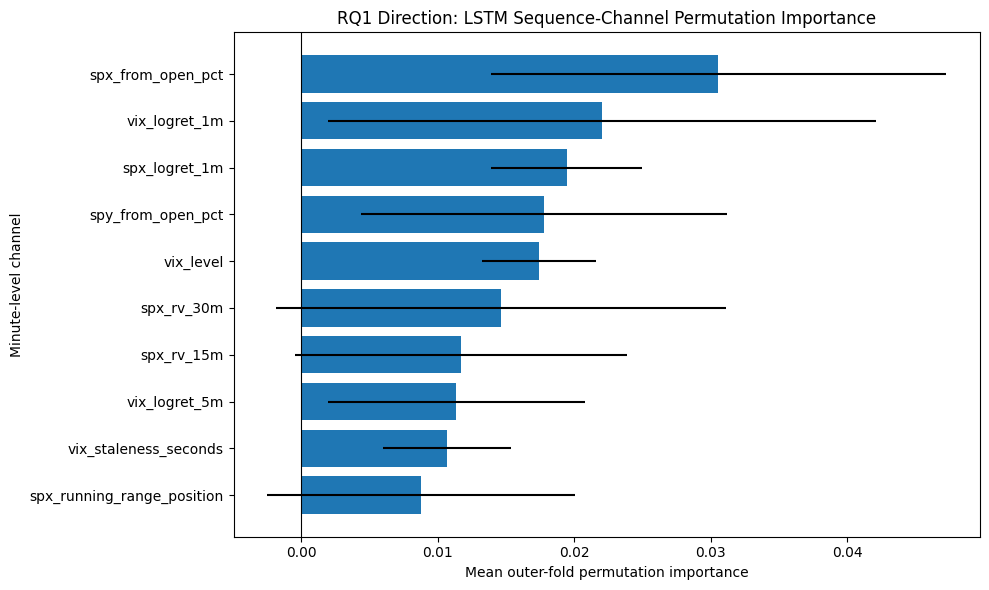

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\figures\lstm_rq1_sequence_importance.png


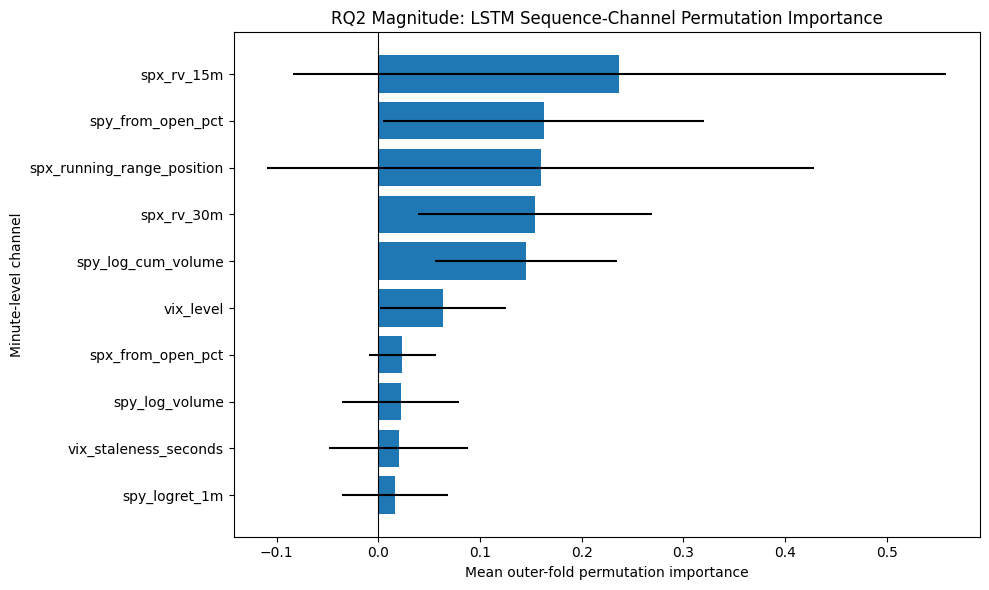

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\figures\lstm_rq2_sequence_importance.png


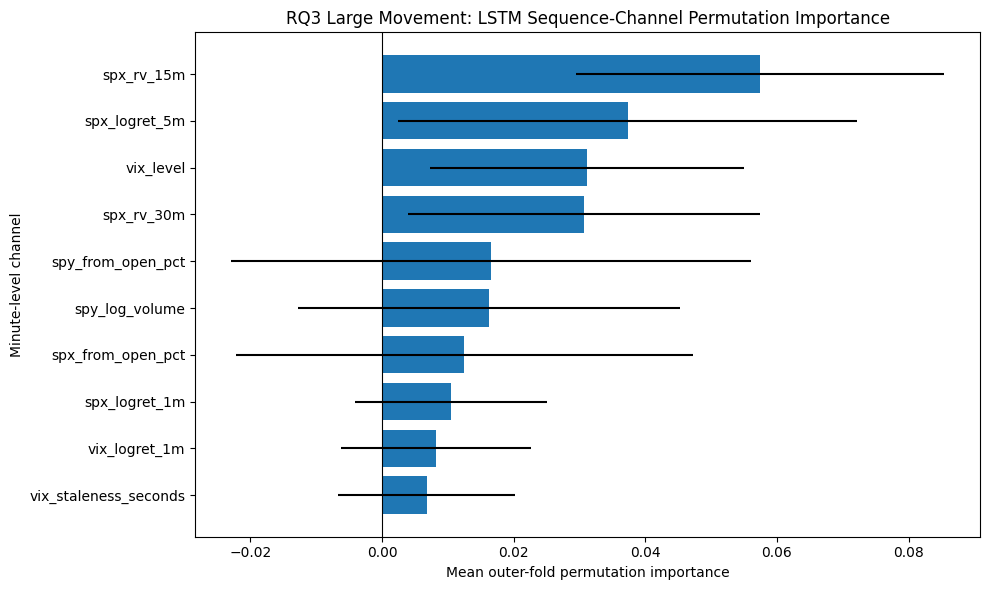

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\figures\lstm_rq3_sequence_importance.png


In [28]:
# I use this cell for plot top temporal channels.
for rq_name, filename in [
    (
        "RQ1 Direction",
        "lstm_rq1_sequence_importance.png",
    ),
    (
        "RQ2 Magnitude",
        "lstm_rq2_sequence_importance.png",
    ),
    (
        "RQ3 Large Movement",
        "lstm_rq3_sequence_importance.png",
    ),
]:
    plot_data = (
        importance_stability[
            importance_stability[
                "research_question"
            ].eq(rq_name)
        ]
        .sort_values(
            "mean_importance"
        )
        .tail(10)
    )

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.barh(
        plot_data["feature"],
        plot_data["mean_importance"],
        xerr=plot_data[
            "between_fold_std"
        ].fillna(0),
    )

    ax.axvline(
        0,
        color="black",
        linewidth=0.8,
    )

    ax.set_title(
        f"{rq_name}: LSTM Sequence-Channel "
        f"Permutation Importance"
    )

    ax.set_xlabel(
        "Mean outer-fold permutation importance"
    )

    ax.set_ylabel(
        "Minute-level channel"
    )

    fig.tight_layout()

    path = (
        FIGURE_ROOT / filename
    )

    fig.savefig(
        path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", path)

## 24. Training/validation loss curves

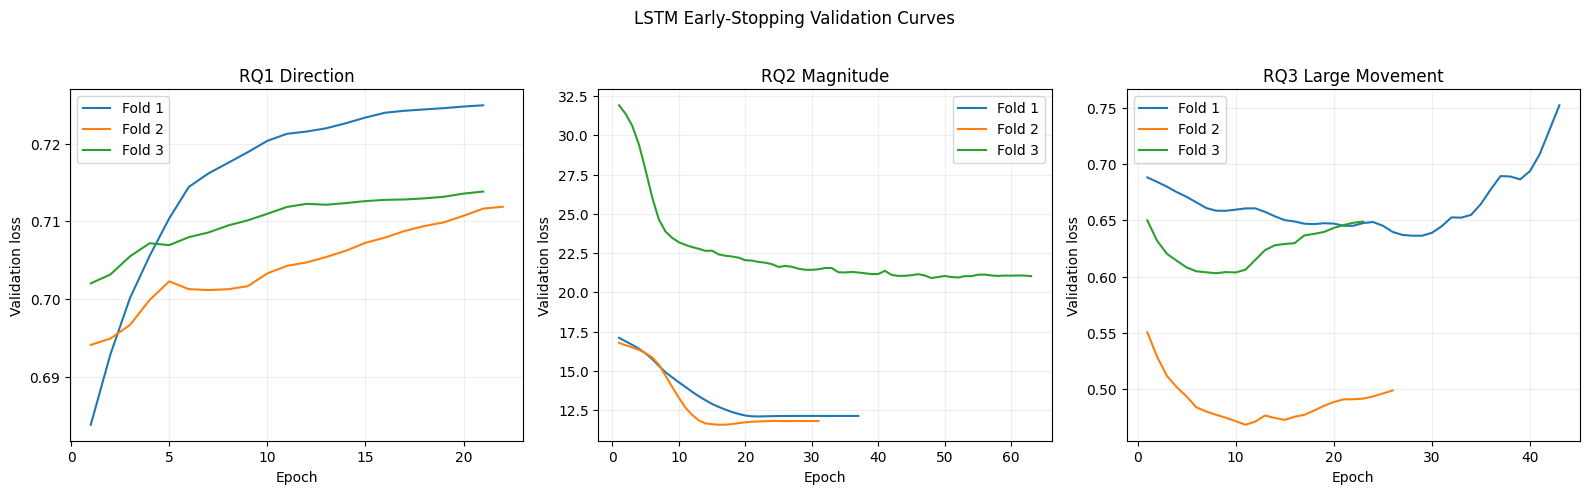

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\figures\lstm_validation_loss_curves.png


In [29]:
# I use this cell for training/validation loss curves.
all_history = pd.concat(
    [
        rq1_history,
        rq2_history,
        rq3_history,
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
)

for ax, rq_name in zip(
    axes,
    [
        "RQ1 Direction",
        "RQ2 Magnitude",
        "RQ3 Large Movement",
    ],
):
    subset = all_history[
        all_history[
            "research_question"
        ].eq(rq_name)
    ]

    for fold, fold_frame in subset.groupby(
        "outer_fold"
    ):
        ax.plot(
            fold_frame["epoch"],
            fold_frame["val_loss"],
            label=f"Fold {fold}",
        )

    ax.set_title(rq_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation loss")
    ax.grid(alpha=0.2)
    ax.legend()

fig.suptitle(
    "LSTM Early-Stopping Validation Curves",
    y=1.02,
)

fig.tight_layout()

history_path = (
    FIGURE_ROOT
    / "lstm_validation_loss_curves.png"
)

fig.savefig(
    history_path,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print("Saved:", history_path)

# Part H — Optional RQ1 confidence diagnostic

## 25. RQ1 confidence-selective performance

As in the earlier robustness work, confidence is measured as distance between the predicted probability and the fold-specific threshold.

This is **diagnostic only**. Percentile selection over an outer test fold should not be treated as a directly executable future trading rule.

In [30]:
# I use this cell for rq1 confidence-selective performance.
rq1_selective_rows = []

rq1_conf = (
    rq1_predictions.copy()
)

rq1_conf["confidence_raw"] = (
    rq1_conf["score"]
    - rq1_conf["threshold"]
).abs()

rq1_conf["confidence_percentile"] = (
    rq1_conf.groupby(
        "outer_fold"
    )["confidence_raw"]
    .rank(
        pct=True,
        method="average",
    )
)

for coverage in [
    1.00,
    0.50,
    0.30,
    0.20,
    0.10,
]:
    selected = rq1_conf[
        rq1_conf[
            "confidence_percentile"
        ]
        > (1.0 - coverage)
    ].copy()

    if selected.empty:
        continue

    rq1_selective_rows.append(
        {
            "requested_coverage": coverage,
            "realised_coverage": (
                len(selected)
                / len(rq1_conf)
            ),
            "sessions": len(selected),
            "balanced_accuracy": (
                balanced_accuracy_score(
                    selected[
                        "y_true"
                    ].astype(int),
                    selected[
                        "prediction"
                    ].astype(int),
                )
            ),
            "accuracy": (
                accuracy_score(
                    selected[
                        "y_true"
                    ].astype(int),
                    selected[
                        "prediction"
                    ].astype(int),
                )
            ),
        }
    )

rq1_selective = pd.DataFrame(
    rq1_selective_rows
)

display(rq1_selective)

,requested_coverage,realised_coverage,sessions,balanced_accuracy,accuracy
0,1.0,1.000000,429,0.530675,0.526807
1,0.5,0.503497,216,0.532432,0.541667
2,0.3,0.300699,129,0.547596,0.550388
3,0.2,0.202797,87,0.562698,0.574713
4,0.1,0.104895,45,0.571429,0.555556


# Part I — Save results

## 26. Save tables

In [31]:
# I use this cell for save tables.
outputs = {
    "lstm_rq1_outer_folds.csv": rq1_folds,
    "lstm_rq1_oof_predictions.csv": rq1_predictions,
    "lstm_rq1_summary.csv": rq1_summary,
    "lstm_rq2_outer_folds.csv": rq2_folds,
    "lstm_rq2_oof_predictions.csv": rq2_predictions,
    "lstm_rq2_summary.csv": rq2_summary,
    "lstm_rq3_outer_folds.csv": rq3_folds,
    "lstm_rq3_oof_predictions.csv": rq3_predictions,
    "lstm_rq3_summary.csv": rq3_summary,
    "lstm_all_oof_predictions.csv": lstm_oof,
    "lstm_sequence_permutation_importance.csv": all_importance,
    "lstm_sequence_importance_stability.csv": importance_stability,
    "lstm_training_history.csv": all_history,
    "lstm_rq1_selective_prediction.csv": rq1_selective,
    "lstm_sequence_quality.csv": sequence_quality,
}

if not overlap_comparison.empty:
    outputs[
        "lstm_vs_classical_oof_overlap.csv"
    ] = overlap_comparison

for filename, frame in outputs.items():
    path = TABLE_ROOT / filename
    frame.to_csv(
        path,
        index=False,
    )
    print("Saved:", path)

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\tables\lstm_rq1_outer_folds.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\tables\lstm_rq1_oof_predictions.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\tables\lstm_rq1_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\tables\lstm_rq2_outer_folds.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\tables\lstm_rq2_oof_predictions.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\tables\lstm_rq2_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\tables\lstm_rq3_outer_folds.csv

## 27. Combined LSTM research-question summary

In [32]:
# I use this cell for combined lstm research-question summary.
combined_summary = pd.DataFrame(
    [
        {
            "research_question": (
                "RQ1 Direction"
            ),
            "primary_metric": (
                "Balanced accuracy"
            ),
            "lstm_score": float(
                rq1_summary.iloc[0][
                    "outer_balanced_accuracy_mean"
                ]
            ),
            "simple_benchmark_score": float(
                max(
                    rq1_summary.iloc[0][
                        "15m_mean_reversion_ba_mean"
                    ],
                    rq1_summary.iloc[0][
                        "60m_mean_reversion_ba_mean"
                    ],
                )
            ),
            "higher_is_better": True,
            "secondary_metric": (
                "ROC AUC"
            ),
            "secondary_score": float(
                rq1_summary.iloc[0][
                    "outer_roc_auc_mean"
                ]
            ),
        },
        {
            "research_question": (
                "RQ2 Magnitude"
            ),
            "primary_metric": (
                "MAE (bps)"
            ),
            "lstm_score": float(
                rq2_summary.iloc[0][
                    "outer_mae_bps_mean"
                ]
            ),
            "simple_benchmark_score": float(
                rq2_summary.iloc[0][
                    "training_median_benchmark_mae_mean"
                ]
            ),
            "higher_is_better": False,
            "secondary_metric": (
                "Spearman"
            ),
            "secondary_score": float(
                rq2_summary.iloc[0][
                    "outer_spearman_mean"
                ]
            ),
        },
        {
            "research_question": (
                "RQ3 Large Movement"
            ),
            "primary_metric": (
                "Average precision"
            ),
            "lstm_score": float(
                rq3_summary.iloc[0][
                    "outer_average_precision_mean"
                ]
            ),
            "simple_benchmark_score": float(
                rq3_summary.iloc[0][
                    "outer_prevalence_mean"
                ]
            ),
            "higher_is_better": True,
            "secondary_metric": (
                "Recall"
            ),
            "secondary_score": float(
                rq3_summary.iloc[0][
                    "outer_recall_mean"
                ]
            ),
        },
    ]
)

display(combined_summary)

combined_summary.to_csv(
    TABLE_ROOT
    / "lstm_research_question_summary.csv",
    index=False,
)

,research_question,primary_metric,lstm_score,simple_benchmark_score,higher_is_better,secondary_metric,secondary_score
0,RQ1 Direction,Balanced accuracy,0.523608,0.552402,True,ROC AUC,0.532917
1,RQ2 Magnitude,MAE (bps),14.396754,14.165494,False,Spearman,0.202818
2,RQ3 Large Movement,Average precision,0.433930,0.240093,True,Recall,0.747475


## 28. Conservative dissertation interpretation generator

The generated text deliberately avoids presenting the LSTM as superior merely because it is more complex.

The main comparison is whether the sequence model:

- beats the simple same-fold benchmark;
- materially improves on the existing classical results;
- or provides no meaningful incremental value.

Review and edit the generated wording before using it in the dissertation.

In [33]:
rq1_score = float(
    rq1_summary.iloc[0][
        "outer_balanced_accuracy_mean"
    ]
)

rq1_mr = float(
    max(
        rq1_summary.iloc[0][
            "15m_mean_reversion_ba_mean"
        ],
        rq1_summary.iloc[0][
            "60m_mean_reversion_ba_mean"
        ],
    )
)

rq2_mae = float(
    rq2_summary.iloc[0][
        "outer_mae_bps_mean"
    ]
)

rq2_benchmark = float(
    rq2_summary.iloc[0][
        "training_median_benchmark_mae_mean"
    ]
)

rq2_spearman = float(
    rq2_summary.iloc[0][
        "outer_spearman_mean"
    ]
)

rq3_ap = float(
    rq3_summary.iloc[0][
        "outer_average_precision_mean"
    ]
)

rq3_prevalence = float(
    rq3_summary.iloc[0][
        "outer_prevalence_mean"
    ]
)

rq3_recall = float(
    rq3_summary.iloc[0][
        "outer_recall_mean"
    ]
)

if rq1_score > rq1_mr:
    rq1_clause = (
        "The LSTM modestly exceeded the strongest same-fold "
        "mean-reversion benchmark for directional prediction."
    )
else:
    rq1_clause = (
        "The LSTM did not exceed the strongest same-fold "
        "mean-reversion benchmark, reinforcing the earlier finding "
        "that final-hour direction is difficult to forecast reliably."
    )

if rq2_mae < rq2_benchmark:
    rq2_clause = (
        "For magnitude prediction, the LSTM improved on the "
        "training-median benchmark."
    )
else:
    rq2_clause = (
        "For magnitude prediction, the LSTM did not improve on the "
        "training-median benchmark."
    )

if rq3_ap > rq3_prevalence:
    rq3_clause = (
        "For large-movement classification, average precision "
        "remained above the event-prevalence benchmark."
    )
else:
    rq3_clause = (
        "For large-movement classification, average precision did "
        "not exceed event prevalence."
    )

if not overlap_comparison.empty:
    comparison_sentences = []

    for row in overlap_comparison.itertuples(
        index=False
    ):
        if row.metric == "mae_bps":
            better = (
                row.lstm_metric
                < row.classical_metric
            )
        else:
            better = (
                row.lstm_metric
                > row.classical_metric
            )

        comparison_sentences.append(
            f"For {row.research_question}, the LSTM "
            f"{'outperformed' if better else 'did not outperform'} "
            f"the selected classical model on the "
            f"{int(row.overlap_sessions)} overlapping OOF sessions "
            f"using {row.metric}."
        )

    overlap_text = " ".join(
        comparison_sentences
    )
else:
    overlap_text = (
        "A session-matched comparison with the classical OOF "
        "predictions was not available."
    )

draft = f"""
### Exploratory LSTM Sequence-Modelling Extension

A recurrent neural-network extension was implemented to test whether retaining
the temporal ordering of intraday observations provided incremental predictive
value beyond the engineered daily feature representation. Each observation
consisted of the 120 one-minute observations from 13:00 through 14:59 ET,
using only information available before the final-hour target period. The
models were evaluated with three expanding chronological outer folds. Within
each outer-training fold, the latest 20% of observations were reserved for
early stopping and, where applicable, classification-threshold selection.

For RQ1, the LSTM achieved mean outer-fold balanced accuracy of
{rq1_score:.3f}, compared with {rq1_mr:.3f} for the strongest same-fold
mean-reversion comparator. {rq1_clause}

For RQ2, mean outer-fold MAE was {rq2_mae:.2f} bps compared with
{rq2_benchmark:.2f} bps for the training-median magnitude benchmark, while
mean Spearman rank correlation was {rq2_spearman:.3f}. {rq2_clause}

For RQ3, mean outer-fold average precision was {rq3_ap:.3f} compared with
mean large-movement prevalence of {rq3_prevalence:.3f}; mean recall was
{rq3_recall:.3f}. {rq3_clause}

{overlap_text}

The LSTM results should be interpreted as an exploratory model-complexity
check rather than a new model-selection exercise. Although the recurrent
architecture can model temporal dependencies directly, the number of
independent observations remains the number of trading sessions rather than
the number of one-minute bars. Consequently, a more complex sequence model
would require a clear and stable improvement over the simpler tabular
approaches to justify its additional modelling complexity.
"""

print(draft)

draft_path = (
    LSTM_ROOT
    / "lstm_dissertation_draft.md"
)

draft_path.write_text(
    draft,
    encoding="utf-8",
)

print("Saved:", draft_path)


### Exploratory LSTM Sequence-Modelling Extension

A recurrent neural-network extension was implemented to test whether retaining
the temporal ordering of intraday observations provided incremental predictive
value beyond the engineered daily feature representation. Each observation
consisted of the 120 one-minute observations from 13:00 through 14:59 ET,
using only information available before the final-hour target period. The
models were evaluated with three expanding chronological outer folds. Within
each outer-training fold, the latest 20% of observations were reserved for
early stopping and, where applicable, classification-threshold selection.

For RQ1, the LSTM achieved mean outer-fold balanced accuracy of
0.524, compared with 0.552 for the strongest same-fold
mean-reversion comparator. The LSTM did not exceed the strongest same-fold mean-reversion benchmark, reinforcing the earlier finding that final-hour direction is difficult to forecast reliably.

For RQ2, mean outer-fold M

## 29. Save reproducibility manifest

In [34]:
# I use this cell for save reproducibility manifest.
manifest = {
    "analysis": (
        "Exploratory LSTM intraday sequence extension"
    ),
    "extended_underlying_period": (
        "2023 through 2026-07-17 source data"
    ),
    "development_splits_used": [
        "Train",
        "Validation",
    ],
    "existing_test_used": (
        RUN_EXISTING_TEST_AS_SECONDARY_CHECK
    ),
    "fresh_post_2026_07_17_holdout_used": False,
    "sequence_window_et": [
        "13:00",
        "14:59",
    ],
    "sequence_length_minutes": (
        SEQUENCE_LENGTH
    ),
    "sequence_features": (
        SEQUENCE_FEATURES
    ),
    "outer_splits": OUTER_SPLITS,
    "inner_validation_fraction": (
        INNER_VALIDATION_FRACTION
    ),
    "architecture": {
        "lstm_units": LSTM_UNITS,
        "dense_units": DENSE_UNITS,
        "dropout_rate": (
            DROPOUT_RATE
        ),
        "learning_rate": (
            LEARNING_RATE
        ),
    },
    "training": {
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": (
            EARLY_STOPPING_PATIENCE
        ),
        "batch_size": BATCH_SIZE,
        "shuffle": False,
    },
    "rq1_primary_metric": (
        "balanced_accuracy"
    ),
    "rq2_primary_metric": (
        "mae_bps"
    ),
    "rq3_primary_metric": (
        "average_precision"
    ),
    "rq3_large_move_threshold_bps": (
        LARGE_MOVE_THRESHOLD_BPS
    ),
    "random_state": RANDOM_STATE,
    "tensorflow_version": (
        tf.__version__
    ),
    "methodology_notes": [
        (
            "Scaling is fitted only on the chronological fit "
            "portion of each outer fold."
        ),
        (
            "The final 20% of each outer-training fold is used "
            "for early stopping and classification-threshold selection."
        ),
        (
            "Outer-test observations are not used for training, scaling, "
            "early stopping, or threshold selection."
        ),
        (
            "The previously inspected Test block is excluded from the "
            "main LSTM evaluation."
        ),
        (
            "The fresh post-17-Jul-2026 holdout remains untouched."
        ),
        (
            "The LSTM architecture is intentionally small and is not "
            "subjected to a large hyperparameter search."
        ),
    ],
}

manifest_path = (
    LSTM_ROOT
    / "lstm_sequence_manifest.json"
)

manifest_path.write_text(
    json.dumps(
        manifest,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

print("Saved:", manifest_path)

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\extended_2023_2026\lstm_sequence_extension\lstm_sequence_manifest.json


## 30. Save exploratory development refits

I use the final chronological 20% of the permitted development sample to choose one epoch count for each research question and to choose the RQ1/RQ3 classification thresholds. I then refit each model from scratch on all Train + Validation sequences for that fixed number of epochs. These are exploratory development refits, not independently evaluated final models, and neither the existing Test block nor the fresh holdout is used.

In [ ]:
# I enable this only when I want to replace the canonical exploratory refits.
SAVE_MODEL_ARTIFACTS = True

import joblib

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.model_artifacts import (
    save_keras_artifact,
    write_model_manifest,
)

LSTM_ARTIFACT_ROOT = PROJECT_ROOT / "models" / "lstm"


def select_and_refit_development_lstm(
    task: str,
    target,
    threshold_objective=None,
    seed_offset: int = 0,
):
    """Select on a chronological tail, then refit on every permitted development row."""
    all_indices = np.arange(len(X_development))
    fit_indices, validation_indices = chronological_fit_validation_split(all_indices)

    (
        X_fit_scaled,
        X_validation_scaled,
        _,
        selection_scaler,
    ) = scale_3d_train_validation_test(
        X_development[fit_indices],
        X_development[validation_indices],
        X_development[validation_indices],
    )

    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE + seed_offset)
    selection_model = build_lstm_model(len(SEQUENCE_FEATURES), task)
    fit_arguments = {
        "x": X_fit_scaled,
        "y": target[fit_indices],
        "validation_data": (
            X_validation_scaled,
            target[validation_indices],
        ),
        "epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "shuffle": False,
        "callbacks": make_callbacks(),
        "verbose": 0,
    }
    if task in {"RQ1", "RQ3"}:
        fit_arguments["class_weight"] = classification_class_weight(
            target[fit_indices]
        )
    history = selection_model.fit(**fit_arguments)
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    threshold = None
    threshold_objective_value = None
    if threshold_objective is not None:
        validation_scores = selection_model.predict(
            X_validation_scaled,
            verbose=0,
        ).reshape(-1)
        threshold, threshold_objective_value = select_threshold(
            target[validation_indices],
            validation_scores,
            objective=threshold_objective,
        )
        threshold = float(threshold)
        threshold_objective_value = float(threshold_objective_value)

    n_features = X_development.shape[-1]
    final_scaler = StandardScaler()
    final_scaler.fit(X_development.reshape(-1, n_features))
    X_all_scaled = final_scaler.transform(
        X_development.reshape(-1, n_features)
    ).reshape(X_development.shape)

    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE + seed_offset)
    final_model = build_lstm_model(len(SEQUENCE_FEATURES), task)
    final_fit_arguments = {
        "x": X_all_scaled,
        "y": target,
        "epochs": best_epoch,
        "batch_size": BATCH_SIZE,
        "shuffle": False,
        "verbose": 0,
    }
    if task in {"RQ1", "RQ3"}:
        final_fit_arguments["class_weight"] = classification_class_weight(target)
    final_model.fit(**final_fit_arguments)

    return {
        "model": final_model,
        "scaler": final_scaler,
        "verification_input": X_all_scaled[:1],
        "best_epoch": best_epoch,
        "classification_threshold": threshold,
        "threshold_objective": threshold_objective,
        "threshold_objective_value": threshold_objective_value,
        "selection_fit_rows": int(len(fit_indices)),
        "selection_validation_rows": int(len(validation_indices)),
    }


def lstm_artifact_metadata(task: str, target_name: str, result: dict):
    return {
        "research_question": task,
        "target": target_name,
        "source_notebook": "11_lstm_intraday_sequence_extension.ipynb",
        "model_family": "small regularised LSTM",
        "artifact_status": "exploratory development refit; not independently evaluated",
        "dataset_variant": "extended 2023-2026 sequence-eligible development sample",
        "features": SEQUENCE_FEATURES,
        "sequence_window_et": ["13:00", "14:59"],
        "sequence_length_minutes": SEQUENCE_LENGTH,
        "training_start": str(development_daily["session_date"].min()),
        "training_end": str(development_daily["session_date"].max()),
        "training_rows": int(len(development_daily)),
        "included_splits": ["Train", "Validation"],
        "excluded_splits": ["Test", "fresh post-2026-07-17 holdout"],
        "classification_threshold": result["classification_threshold"],
        "threshold_objective": result["threshold_objective"],
        "threshold_objective_value": result["threshold_objective_value"],
        "best_epoch": result["best_epoch"],
        "selection_fit_rows": result["selection_fit_rows"],
        "selection_validation_rows": result["selection_validation_rows"],
        "best_parameters": {
            "lstm_units": LSTM_UNITS,
            "dense_units": DENSE_UNITS,
            "dropout_rate": DROPOUT_RATE,
            "learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE,
            "shuffle": False,
        },
        "library_versions": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "tensorflow": tf.__version__,
            "keras": getattr(keras, "__version__", "bundled with TensorFlow"),
            "joblib": joblib.__version__,
        },
    }


if SAVE_MODEL_ARTIFACTS:
    lstm_specs = [
        ("RQ1", "target_up", y_rq1, "balanced_accuracy", 300, "rq1_direction"),
        ("RQ2", "target_magnitude_bps", y_rq2, None, 400, "rq2_magnitude"),
        ("RQ3", "target_large_move", y_rq3, "f1", 500, "rq3_large_move"),
    ]
    lstm_artifacts = []
    for task, target_name, target, objective, seed_offset, stem in lstm_specs:
        result = select_and_refit_development_lstm(
            task,
            target,
            threshold_objective=objective,
            seed_offset=seed_offset,
        )
        record = save_keras_artifact(
            result["model"],
            LSTM_ARTIFACT_ROOT / f"{stem}.keras",
            result["scaler"],
            LSTM_ARTIFACT_ROOT / f"{stem}_scaler.joblib",
            lstm_artifact_metadata(task, target_name, result),
            keras_loader=keras.models.load_model,
            relative_to=PROJECT_ROOT,
            verification_input=result["verification_input"],
        )
        lstm_artifacts.append(record)
        print("Saved and reloaded:", record["artifact_path"])

    lstm_artifact_manifest = write_model_manifest(
        LSTM_ARTIFACT_ROOT / "manifest.json",
        lstm_artifacts,
        metadata={
            "artifact_set": "exploratory RQ1-RQ3 LSTM development refits",
            "fit_policy": "chronological selection followed by Train + Validation refit",
            "independent_evaluation_status": "not independently evaluated",
            "replacement_policy": "atomic canonical overwrite",
        },
    )
    print("Saved:", lstm_artifact_manifest)
else:
    print("Model saving is disabled; no artifact files were created.")

# 31. Interpretation checklist

After the run finishes, I interpret the results in this order:

### RQ1

Compare the LSTM balanced accuracy with the **15-minute and 60-minute mean-reversion rules on the same outer folds**.

A complex LSTM should not be considered an improvement if it cannot outperform those simple rules.

### RQ2

Focus on:

- MAE against the training-median benchmark;
- R²;
- Spearman correlation.

As with the tabular models, ranking ability may be more economically useful than exact point prediction.

### RQ3

Compare average precision with large-movement prevalence.

A meaningful result requires AP to remain clearly above prevalence across the temporal folds.

### Classical comparison

Use the date-overlap OOF table when available. It is more defensible than comparing headline metrics calculated on different strict/relaxed samples.

### Complexity conclusion

The key dissertation question is not:

> "Did an LSTM work?"

It is:

> **"Did preserving minute-by-minute temporal order add enough predictive value to justify a more complex recurrent model?"**

If the answer is no, that strengthens the case for the simpler engineered-feature approach rather than weakening the dissertation.

After this stage, I avoid further model proliferation unless it addresses a specific methodological limitation. The empirical modelling stage should then be considered complete.